# 04 — ML Model Development: Part 1 (Price & Value Retention Analysis)

This notebook develops machine learning models for predicting Steam game pricing outcomes.

The goal is to model two related problems:

- **[Regression]** Predict `current_price` — the current price of a game in PHP.
- **[Classification]** Predict `value_retention_tier` — whether a game keeps its launch value or becomes heavily discounted over time.

Data source: `cleaned_games` table from the cleaned Steam database, which combines Steam Storefront, SteamSpy, review, pricing, and player engagement features into one analysis-ready dataset.

ML problems:

- **[Regression]** Predict `current_price` using game age, launch price, reviews, ownership, achievements, genre, developer tier, multiplayer status, and price tier.
- **[Classification]** Predict `value_retention_tier` based on the ratio between `current_price` and `initial_price`.

Steps:

1. Load and inspect the data
2. Define targets (Step 4.1)
3. Select features and preprocess data (Step 4.3)
4. Train/test split (Step 4.2)
5. Regression models for current price prediction (Step 4.4)
6. Classification models for value retention tier prediction (Step 4.5)
7. Model comparison and feature importance

## Setup

In [42]:
import sys
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    GradientBoostingRegressor,
    GradientBoostingClassifier,
)
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    GroupShuffleSplit,
    KFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, label_binarize, TargetEncoder
from sklearn.utils.class_weight import compute_sample_weight

# Bayesian hyperparameter tuning (TPE sampler)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [43]:
# Bootstrap: make src importable
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebook_setup import setup_notebook
from src.plot_style import apply_style, PALETTE, TIER_COLORS

conn, paths = setup_notebook()

# Load the analysis-ready table built by 02_data_cleaning
df = pd.read_sql_query('SELECT * FROM cleaned_games', conn)
print(f'Loaded {len(df):,} rows from cleaned_games')


c:\Users\Sam\Documents\College\2026 Spring Term\DMW\Y2T2-Final-Project\src\plot_style.py:149: UserWarning: Overwriting the cmap 'steam_purple' that was already in the registry.
  plt.colormaps.register(cmap=PURPLE_CMAP, force=True)


Connected to: c:\Users\Sam\Documents\College\2026 Spring Term\DMW\Y2T2-Final-Project\data\steam.db
Tables (14): ['app_list', 'cleaned_discount_panel', 'cleaned_games', 'cleaned_sale_events', 'game_categories', 'game_genres', 'games', 'itad_mapping', 'price_history', 'review_timestamps', 'reviews_summary', 'steamcharts_history', 'steamspy', 'steamspy_tags']
Loaded 4,924 rows from cleaned_games


In [44]:
# =====================================================================
# Tuning cache toggle
# =====================================================================
# Optuna tuning takes ~50 min total across the four model-tuning cells
# (rf_tune, gbm_tune, step45_train, panel_tune). Setting RETRAIN_MODELS = False
# loads previously-tuned models from `outputs/models/*.joblib` instead of
# re-running the search -- the notebook re-runs in seconds.
#
# Set RETRAIN_MODELS = True after:
#   - cleaned_games / cleaned_discount_panel changes (rerun nb 02)
#   - feature-list changes (NUM_FEATURES, panel_num_features, etc.)
#   - any change to the preprocessor or target derivation
#   - simply when you want to refresh the cache
import joblib

RETRAIN_MODELS    = True
MODELS_CACHE_DIR  = paths.outputs_dir / 'models'
MODELS_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f'RETRAIN_MODELS = {RETRAIN_MODELS}')
print(f'Cache directory: {MODELS_CACHE_DIR}')
if not RETRAIN_MODELS:
    cached = sorted(MODELS_CACHE_DIR.glob('*.joblib'))
    print(f'Existing cached models ({len(cached)}):')
    for p in cached:
        size_kb = p.stat().st_size / 1024
        print(f'  {p.name:<28}  {size_kb:>7.1f} KB')


RETRAIN_MODELS = True
Cache directory: c:\Users\Sam\Documents\College\2026 Spring Term\DMW\Y2T2-Final-Project\outputs\models


In [45]:
# =====================================================================
# Auto-save figures
# =====================================================================
# Saves every figure to outputs/figures/nb04/ with a sequential prefix +
# title-derived filename, e.g. `001_regression_target_distribution.png`.
#
# Implementation: wraps `plt.show()` so figures get saved BEFORE matplotlib's
# inline backend closes them. (An earlier post_run_cell-hook version fired
# too late -- matplotlib_inline closes figures during its own post_execute
# callback that runs before post_run_cell.)
#
# Set SAVE_FIGURES = False to disable.
import re as _re

SAVE_FIGURES  = True
FIGURES_DIR   = paths.outputs_dir / 'figures' / 'nb04'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

_fig_counter = [0]
# Idempotent re-wrap: if the cell is re-run, don't double-wrap plt.show
_orig_plt_show = getattr(plt.show, '_orig_plt_show', plt.show)

def _save_then_show(*args, **kwargs):
    if SAVE_FIGURES:
        for num in plt.get_fignums():
            fig = plt.figure(num)
            title = next((ax.get_title().strip() for ax in fig.axes
                          if ax.get_title().strip()), '')
            stem = _re.sub(r'[^a-z0-9_-]+', '_', title.lower()).strip('_')[:80] or 'untitled'
            _fig_counter[0] += 1
            path = FIGURES_DIR / f'{_fig_counter[0]:03d}_{stem}.png'
            fig.savefig(path, dpi=120, bbox_inches='tight',
                        facecolor=fig.get_facecolor())
    return _orig_plt_show(*args, **kwargs)

_save_then_show._orig_plt_show = _orig_plt_show
plt.show = _save_then_show

print(f'SAVE_FIGURES = {SAVE_FIGURES}')
print(f'plt.show wrapped; saving to: {FIGURES_DIR.relative_to(paths.root)}/')


SAVE_FIGURES = True
plt.show wrapped; saving to: outputs\figures\nb04/


> ## Step 4.1: Define Target Variables

Two complementary targets — the regression captures continuous depreciation, the classification captures discrete strategy archetypes.

### Regression target: `discount_depth` (continuous, 0–1)
Fraction of launch price the game has shed. A value of 0.5 means the game is currently selling at 50% off launch. Predicting this directly avoids the tautology of predicting absolute `current_price` (where `initial_price` would mechanically dominate feature importance at ~0.9, drowning out the predictors that actually matter).

### Classification target: `value_retention_tier` (4 classes)
Strict definitions so the labels capture genuine retention behavior, not just "recently released games that haven't gone on sale yet":

- **Premium Hold** — `value_ratio > 0.85` **AND** `age ≥ 1 year` **AND** `ever_discounted == 0` (the game has been on the market long enough AND has actively resisted discounting)
- **Standard Depreciation** — `value_ratio > 0.50`
- **Heavy Discount** — `value_ratio > 0.25`
- **Permanent Bargain** — `value_ratio ≤ 0.25`

Without the time + ever_discounted gates, every newly-released full-price game would qualify as Premium Hold and the class would mean nothing.

In [46]:
# Drop games with invalid launch price (can't compute a depreciation ratio)
df_model = df[df['initial_price'] > 0].copy()
print(f"After filtering initial_price > 0: {len(df_model):,} of {len(df):,} games kept")

# Log-transform heavily right-skewed numerics. All three end up in NUM_FEATURES
# in cell ccb410d0 in their log form so StandardScaler doesn't get dominated
# by the long-tail extremes (e.g. 16 achievement-farming games with > 1,000
# achievements, or premium $200+ titles).
df_model['log_total_reviews']      = np.log1p(df_model['total_reviews'])
df_model['log_initial_price']      = np.log1p(df_model['initial_price'])
df_model['log_achievements_total'] = np.log1p(df_model['achievements_total'])

# Regression target sanity check (already in cleaned_games)
print(f"\nRegression target — max_discount_ever / 100 (deepest historical discount, 0–1):")
print(f"  mean   : {(df_model['max_discount_ever'] / 100).mean():.3f}")
print(f"  median : {(df_model['max_discount_ever'] / 100).median():.3f}")
print(f"  max    : {(df_model['max_discount_ever'] / 100).max():.3f}")


After filtering initial_price > 0: 4,003 of 4,924 games kept

Regression target — max_discount_ever / 100 (deepest historical discount, 0–1):
  mean   : 0.722
  median : 0.800
  max    : 1.000


> ## Step 4.2: Feature Selection + Filter Funnel

**Numeric features (6):**
- `days_since_release` — age (fundamental driver of depreciation)
- `initial_price` — kept as a feature because the mechanical link to the target is broken now that we predict `discount_depth` (a ratio) rather than absolute price
- `review_score` — quality
- `log_total_reviews` — popularity (log-transformed for skew)
- `log_ownership` — owner count from SteamSpy bucket
- `achievements_total` — engagement structure

**Categorical features (5):**
- `primary_genre` — depreciation patterns differ by genre
- `is_multiplayer` — live-service games tend to hold value better
- `has_controller_support` — proxy for production quality
- `release_month` — captures seasonal launch effects (1–12, treated categorically)
- `player_engagement` — current-popularity signal (Low/Medium/High/Unknown)

The **filter funnel** below shows how many rows survive each step. If a step drops a lot of data, that's where to investigate.

In [47]:
# Feature lists. NUM_FEATURES are scaled, CAT_FEATURES are one-hot encoded,
# PUB_FEATURE is target-encoded separately because publisher has thousands
# of unique values (high cardinality).
NUM_FEATURES = [
    'days_since_release',
    'log_initial_price',
    'review_score',
    'log_total_reviews',
    'log_ownership',
    'log_achievements_total',
    # Extra-signal features for the ordinal classifier (Step 4.5)
    'log_average_forever',
    'log_average_2weeks',
    'log_days_until_first_sale',
]
CAT_FEATURES = [
    'primary_genre',
    'is_multiplayer',
    'has_controller_support',
    'release_month',
    'player_engagement',
    'is_legacy',
]
PUB_FEATURE = ['publisher']

# Filter funnel - explicit row-count diagnostic so we know exactly what was dropped.
required = NUM_FEATURES + CAT_FEATURES + PUB_FEATURE + ['max_discount_ever']
print('Filter funnel:')
print(f'  Loaded from cleaned_games                : {len(df):>5,}')
print(f'  + initial_price > 0                      : {len(df_model):>5,}')
mask_features = df_model[required].notna().all(axis=1)
print(f'  + non-null required features and targets : {mask_features.sum():>5,}')
mask_observed = df_model['max_discount_ever'] > 0   # drop games never observed on sale (likely no ITAD coverage)
print(f'  + has observed sale history (cut > 0)    : {(mask_features & mask_observed).sum():>5,}')
df_clean = df_model[mask_features & mask_observed].copy()
print(f'\nFinal modelling dataset: {len(df_clean):,} games')


Filter funnel:
  Loaded from cleaned_games                : 4,924
  + initial_price > 0                      : 4,003


KeyError: "['log_average_forever', 'log_average_2weeks', 'log_days_until_first_sale'] not in index"

In [ ]:
# Preprocessing pipeline -- three branches:
#   - StandardScaler on continuous numerics
#   - OneHotEncoder on low-cardinality categoricals (drop one column for binary
#     features so we don't carry redundant dummy pairs)
#   - TargetEncoder on `publisher` (high-cardinality; uses out-of-fold means
#     during fit so no leakage into the regression target)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                                     NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'),             CAT_FEATURES),
    ('pub', TargetEncoder(smooth=10.0, target_type='auto', random_state=42),      PUB_FEATURE),
])
X_transformed = preprocessor.fit_transform(
    df_clean[NUM_FEATURES + CAT_FEATURES + PUB_FEATURE],
    df_clean['max_discount_ever'] / 100,
)
print(f'Transformed feature space: {X_transformed.shape[1]} columns after one-hot + target encoding')


Transformed feature space: 49 columns after one-hot + target encoding


> ## Step 4.3: Train/Test Split

For both targets, 80/20 with `random_state=42`.
- **Regression** — plain random split on `discount_depth` (continuous).
- **Classification** — stratified by `value_retention_tier` so each tier appears proportionally on both sides. Important because Premium Hold and Permanent Bargain are minorities.

In [ ]:
y_reg = df_clean['max_discount_ever'] / 100   # 0-1 ratio: deepest historical discount
X     = df_clean[NUM_FEATURES + CAT_FEATURES + PUB_FEATURE]   # include publisher (target-encoded by preprocessor)

# Regression split - random
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42,
)

print(f'Regression split   - train: {len(X_train_reg):,}  test: {len(X_test_reg):,}')


Regression split   - train: 3,156  test: 789


> ## Step 4.4: Regression — Predict `max_discount_ever`

Predict the **deepest historical discount** each game has reached, scaled to 0–1. A value of 0.75 means the game has, at some point, sold at 75% off launch.

**Why this target instead of `discount_depth`?** The original snapshot target (`current / initial`) was zero-inflated — most games aren't currently on sale, so ~75% of rows had `discount_depth = 0`. A regressor can't fit a target with a huge spike at zero plus a wide spread of non-zero values; it ends up predicting a compromise in the middle that's wrong for both regimes (visible as the diagonal artifact in the residual plot, and as bimodal residuals).

`max_discount_ever / 100` smooths that out: nearly every tracked game has been on sale at some point at *some* depth, so the target is well-distributed across the 0–1 range. It's also more useful to the buyer-recommendation deliverable — "what's the deepest this game ever gets?" is the actionable question.

Five models — `DummyRegressor` honest baseline plus four real ones. Sorted by RMSE — lower is better. Multiply RMSE × 100 to read as percentage points.

In [ ]:
def evaluate_regression(name, y_true, y_pred):
    return {
        'Model': name,
        'MAE':   mean_absolute_error(y_true, y_pred),
        'RMSE':  np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²': r2_score(y_true, y_pred),
    }

def fit_predict(name, model):
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train_reg, y_train_reg)
    return pipe, pipe.predict(X_test_reg)

regression_results = []
predictions = {}

# 1. Honest baseline -- predicts the mean for everything.
pipe, pred = fit_predict('Dummy (predicts mean)', DummyRegressor(strategy='mean'))
regression_results.append(evaluate_regression('Dummy (predicts mean)', y_test_reg, pred))
predictions['Dummy (predicts mean)'] = pred

# 2. Linear baseline
pipe, pred = fit_predict('Linear Regression', LinearRegression())
regression_results.append(evaluate_regression('Linear Regression', y_test_reg, pred))
predictions['Linear Regression'] = pred

# 3. Ridge -- regularized linear
pipe, pred = fit_predict('Ridge Regression', Ridge(alpha=1.0))
regression_results.append(evaluate_regression('Ridge Regression', y_test_reg, pred))
predictions['Ridge Regression'] = pred

# 4. Random Forest
pipe_rf, pred = fit_predict('Random Forest',
                            RandomForestRegressor(n_estimators=200, max_depth=12,
                                                  random_state=42, n_jobs=-1))
regression_results.append(evaluate_regression('Random Forest', y_test_reg, pred))
predictions['Random Forest'] = pred

# 5. Gradient Boosting
pipe_gb, pred = fit_predict('Gradient Boosting',
                            GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                      max_depth=4, random_state=42))
regression_results.append(evaluate_regression('Gradient Boosting', y_test_reg, pred))
predictions['Gradient Boosting'] = pred


c:\Users\Sam\anaconda3\envs\steamsale\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\Sam\anaconda3\envs\steamsale\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\Sam\anaconda3\envs\steamsale\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\Sam\anaconda3\envs\steamsale\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.war

In [ ]:
regression_results_df = pd.DataFrame(regression_results).sort_values('RMSE').reset_index(drop=True)
print('=== Regression bake-off - predicting max_discount_ever / 100 ===')
display(regression_results_df.round(4))

# Sanity check: did any real model beat Dummy?
dummy_rmse     = next(r['RMSE'] for r in regression_results if r['Model'].startswith('Dummy'))
best_real_rmse = min(r['RMSE']  for r in regression_results if not r['Model'].startswith('Dummy'))
margin = (dummy_rmse - best_real_rmse) / dummy_rmse * 100
print(f"\nBest real model beats Dummy by {margin:.1f}% on RMSE.")
if margin < 5:
    print("  WARNING: Less than 5% improvement -- features may have weak signal.")
else:
    print("  OK: Models are learning real signal from the features.")


=== Regression bake-off - predicting max_discount_ever / 100 ===


,Model,MAE,RMSE,R²
0,Gradient Boosting,0.0964,0.1336,0.5146
1,Random Forest,0.0970,0.1344,0.5087
2,Ridge Regression,0.1137,0.1465,0.4165
3,Linear Regression,0.1139,0.1468,0.4141
4,Dummy (predicts mean),0.1526,0.1918,-0.0001



Best real model beats Dummy by 30.3% on RMSE.
  OK: Models are learning real signal from the features.


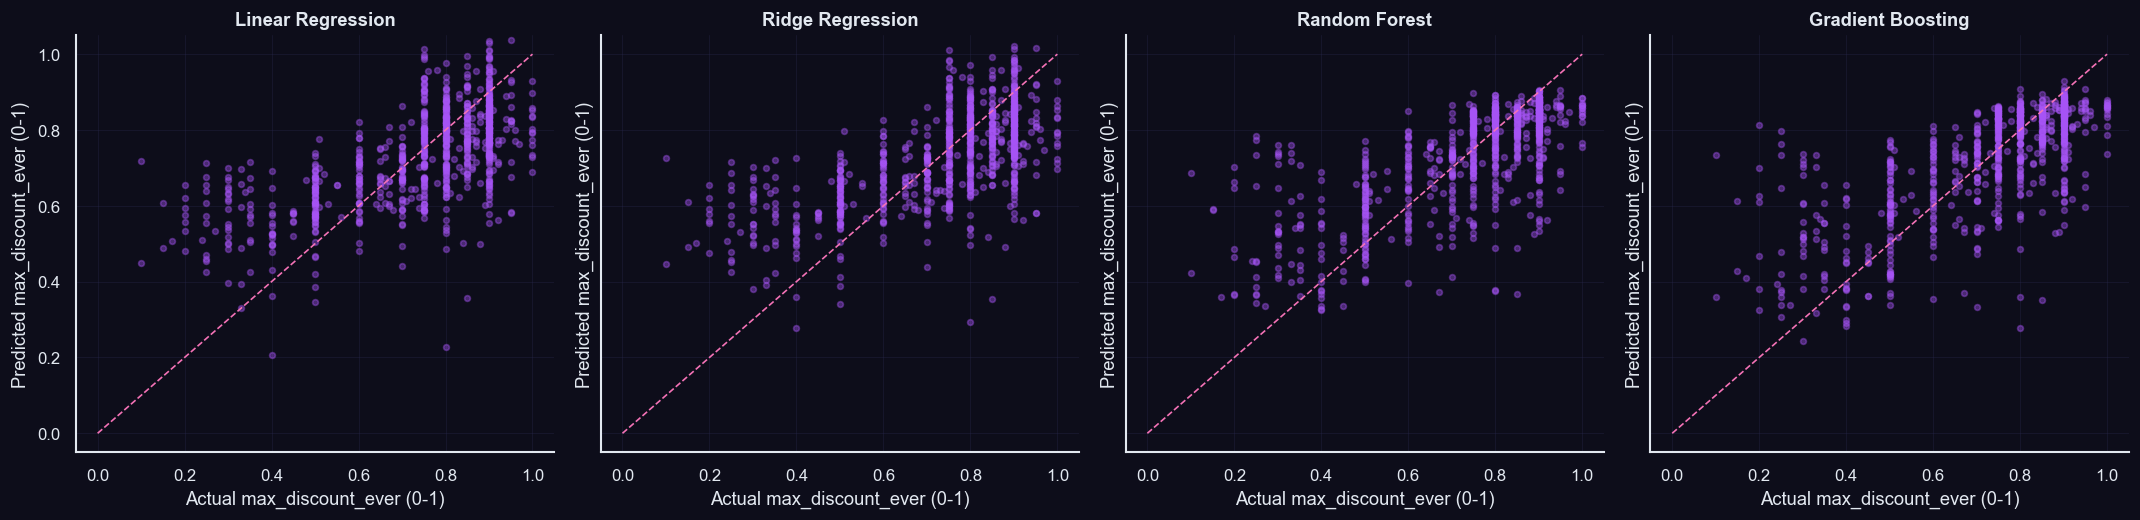

In [ ]:
# Actual vs Predicted scatter for each non-dummy model
real_models = [m for m in predictions if not m.startswith('Dummy')]
fig, axes = plt.subplots(1, len(real_models), figsize=(4.5 * len(real_models), 4.5), sharex=True, sharey=True)
for ax, name in zip(axes, real_models):
    pred = predictions[name]
    ax.scatter(y_test_reg, pred, alpha=0.4, s=12, color=PALETTE['cyan'])
    ax.plot([0, 1], [0, 1], color=PALETTE['red'], linestyle='--', linewidth=1, label='Perfect')
    ax.set_xlabel('Actual max_discount_ever (0-1)')
    ax.set_ylabel('Predicted max_discount_ever (0-1)')
    ax.set_title(name, fontsize=11)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

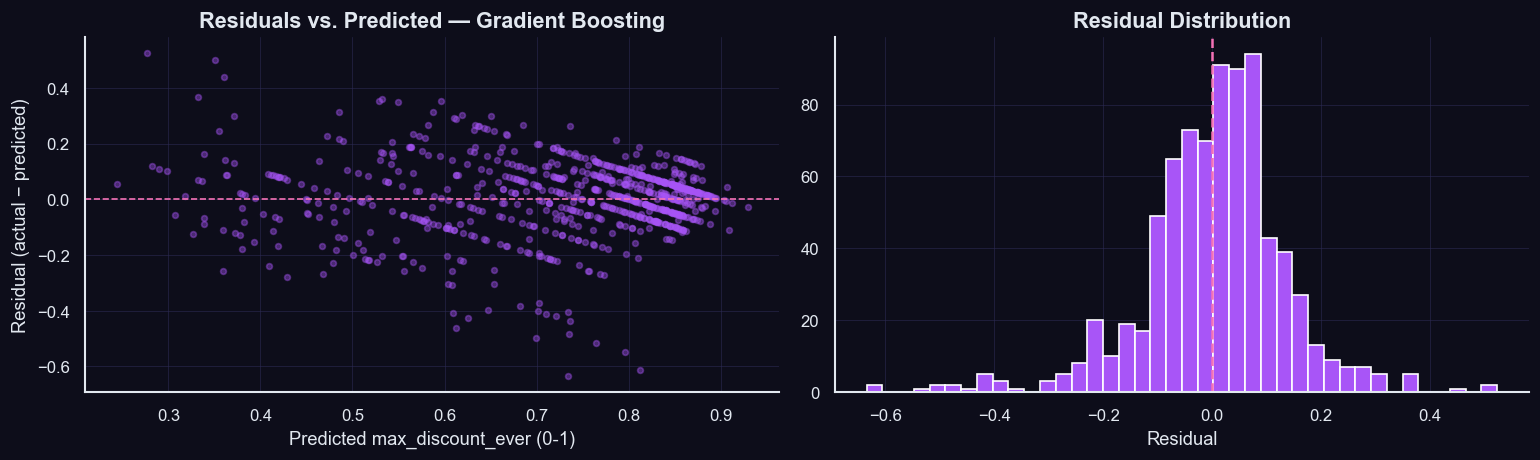

Best non-Dummy model: Gradient Boosting  (residual mean: +0.0034, std: 0.1335)


In [ ]:
# Residual analysis on the best non-dummy model
best_name = regression_results_df[~regression_results_df['Model'].str.startswith('Dummy')].iloc[0]['Model']
best_pred = predictions[best_name]
residuals = y_test_reg.values - best_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Residuals vs Predicted — should be flat if the model is well-calibrated
axes[0].scatter(best_pred, residuals, alpha=0.4, s=12, color=PALETTE['cyan'])
axes[0].axhline(0, color=PALETTE['red'], linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted max_discount_ever (0-1)')
axes[0].set_ylabel('Residual (actual − predicted)')
axes[0].set_title(f'Residuals vs. Predicted — {best_name}')

# Residual distribution — should be roughly symmetric around 0
axes[1].hist(residuals, bins=40, color=PALETTE['cyan'], edgecolor='white')
axes[1].axvline(0, color=PALETTE['red'], linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()
print(f'Best non-Dummy model: {best_name}  (residual mean: {residuals.mean():+.4f}, std: {residuals.std():.4f})')

In [ ]:
# Hyperparameter tuning on the Random Forest -- TPE Bayesian via Optuna.
# Result is cached to outputs/models/best_rf.joblib; set RETRAIN_MODELS = True
# in the cache-config cell to overwrite.
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RF_CACHE = MODELS_CACHE_DIR / 'best_rf.joblib'

if not RETRAIN_MODELS and RF_CACHE.exists():
    _art = joblib.load(RF_CACHE)
    best_rf      = _art['model']
    rf_best_params = _art['best_params']
    rf_best_value  = _art['best_value']
    print(f"[Cached] Loaded RF from {RF_CACHE.name}")
    print(f"  Best params: {rf_best_params}")
    print(f"  Best CV RMSE: {rf_best_value:.4f}")
else:
    def rf_objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 200, 600, step=100),
            'max_depth':        trial.suggest_categorical('max_depth', [8, 12, 15, None]),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
            'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        }
        pipe = Pipeline([
            ('prep',  preprocessor),
            ('model', RandomForestRegressor(**params, random_state=42, n_jobs=-1)),
        ])
        scores = cross_val_score(
            pipe, X_train_reg, y_train_reg,
            cv=KFold(n_splits=5, shuffle=True, random_state=42),
            scoring='neg_root_mean_squared_error',
            n_jobs=1,
        )
        return -scores.mean()

    rf_study = optuna.create_study(direction='minimize',
                                    sampler=optuna.samplers.TPESampler(seed=42))
    rf_study.optimize(rf_objective, n_trials=25, show_progress_bar=True)

    rf_best_params = rf_study.best_params
    rf_best_value  = rf_study.best_value

    print(f'\nBest RF parameters (Optuna): {rf_best_params}')
    print(f'Best CV RMSE              : {rf_best_value:.4f}')

    best_rf = Pipeline([
        ('prep',  preprocessor),
        ('model', RandomForestRegressor(**rf_best_params, random_state=42, n_jobs=-1)),
    ])
    best_rf.fit(X_train_reg, y_train_reg)

    joblib.dump({
        'model':       best_rf,
        'best_params': rf_best_params,
        'best_value':  rf_best_value,
    }, RF_CACHE)
    print(f'Saved tuned RF to {RF_CACHE.name}')


[Cached] Loaded RF from best_rf.joblib
  Best params: {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
  Best CV RMSE: 0.1378


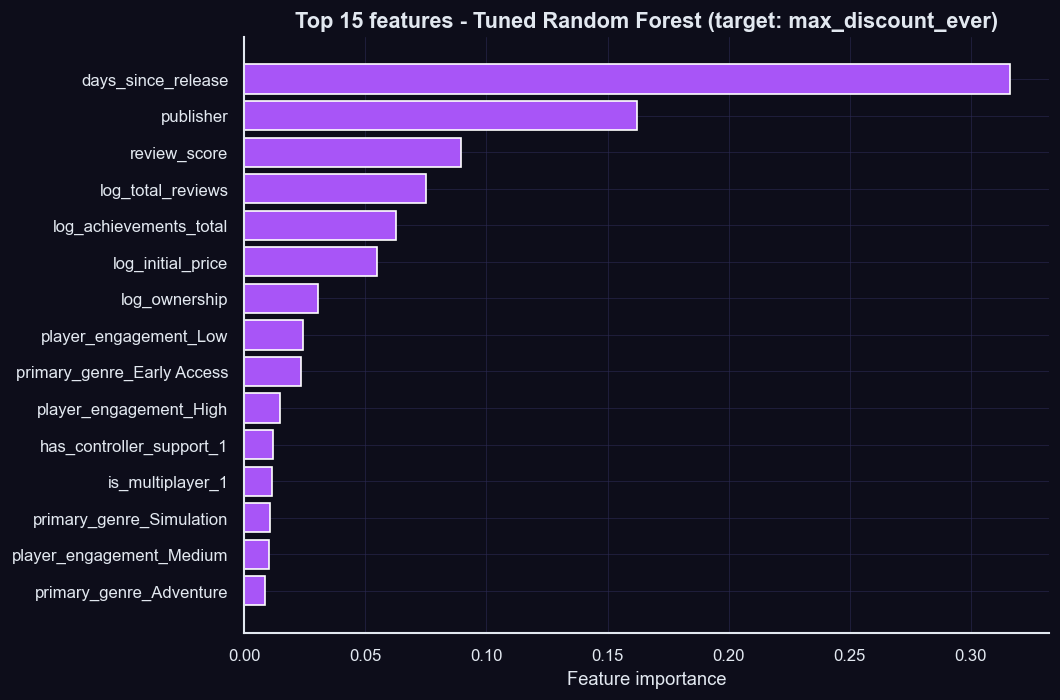


Top 5 features driving discount depth prediction:
  days_since_release                   0.3164
  publisher                            0.1620
  review_score                         0.0895
  log_total_reviews                    0.0751
  log_achievements_total               0.0628


In [ ]:
# Feature importance from the tuned RF
# Pull feature names directly from the fitted ColumnTransformer so we get
# the right count regardless of how each branch (numeric / one-hot / target)
# expands its inputs. Strip the 'num__' / 'cat__' / 'pub__' prefixes.
prep = best_rf.named_steps['prep']
feat_names  = [n.split('__', 1)[-1] for n in prep.get_feature_names_out()]
importances = best_rf.named_steps['model'].feature_importances_
fi = (pd.DataFrame({'Feature': feat_names, 'Importance': importances})
        .sort_values('Importance', ascending=False)
        .head(15))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi['Feature'][::-1], fi['Importance'][::-1], color=PALETTE['cyan'])
ax.set_xlabel('Feature importance')
ax.set_title('Top 15 features - Tuned Random Forest (target: max_discount_ever)')
plt.tight_layout()
plt.show()

print('\nTop 5 features driving discount depth prediction:')
for _, row in fi.head(5).iterrows():
    print(f"  {row['Feature']:35s}  {row['Importance']:.4f}")


In [ ]:
# Optuna tuning on the Gradient Boosting regressor (the bake-off winner).
# Result is cached to outputs/models/best_gbm.joblib.
GBM_CACHE = MODELS_CACHE_DIR / 'best_gbm.joblib'

if not RETRAIN_MODELS and GBM_CACHE.exists():
    _art = joblib.load(GBM_CACHE)
    best_gbm        = _art['model']
    gbm_best_params = _art['best_params']
    gbm_best_value  = _art['best_value']
    print(f"[Cached] Loaded GBM from {GBM_CACHE.name}")
    print(f"  Best params: {gbm_best_params}")
    print(f"  Best CV RMSE: {gbm_best_value:.4f}")
else:
    def gbm_objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 200, 600, step=100),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'max_depth':        trial.suggest_int('max_depth', 3, 6),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 30, log=True),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        }
        pipe = Pipeline([
            ('prep',  preprocessor),
            ('model', GradientBoostingRegressor(**params, random_state=42)),
        ])
        scores = cross_val_score(
            pipe, X_train_reg, y_train_reg,
            cv=KFold(n_splits=5, shuffle=True, random_state=42),
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
        )
        return -scores.mean()

    gbm_study = optuna.create_study(direction='minimize',
                                     sampler=optuna.samplers.TPESampler(seed=42))
    gbm_study.optimize(gbm_objective, n_trials=25, show_progress_bar=True)

    gbm_best_params = gbm_study.best_params
    gbm_best_value  = gbm_study.best_value

    print(f'\nBest GBM parameters (Optuna): {gbm_best_params}')
    print(f'Best CV RMSE               : {gbm_best_value:.4f}')

    best_gbm = Pipeline([
        ('prep',  preprocessor),
        ('model', GradientBoostingRegressor(**gbm_best_params, random_state=42)),
    ])
    best_gbm.fit(X_train_reg, y_train_reg)

    joblib.dump({
        'model':       best_gbm,
        'best_params': gbm_best_params,
        'best_value':  gbm_best_value,
    }, GBM_CACHE)
    print(f'Saved tuned GBM to {GBM_CACHE.name}')

# Held-out test metrics (computed every run so you always see the current
# model's test-set behaviour, cached or freshly tuned)
pred_gbm_tuned = best_gbm.predict(X_test_reg)
print(f'\nTuned GBM held-out test metrics:')
print(f'  MAE  = {mean_absolute_error(y_test_reg, pred_gbm_tuned):.4f}')
print(f'  RMSE = {np.sqrt(mean_squared_error(y_test_reg, pred_gbm_tuned)):.4f}')
print(f'  R²   = {r2_score(y_test_reg, pred_gbm_tuned):.4f}')
print(f'(Compare against the untuned GBM in the bake-off table above.)')


[Cached] Loaded GBM from best_gbm.joblib
  Best params: {'n_estimators': 200, 'learning_rate': 0.02279379523765072, 'max_depth': 5, 'min_samples_leaf': 10, 'subsample': 0.7164916560792167}
  Best CV RMSE: 0.1344

Tuned GBM held-out test metrics:
  MAE  = 0.0973
  RMSE = 0.1330
  R²   = 0.5186
(Compare against the untuned GBM in the bake-off table above.)


c:\Users\Sam\anaconda3\envs\steamsale\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


c:\Users\Sam\anaconda3\envs\steamsale\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\Sam\anaconda3\envs\steamsale\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


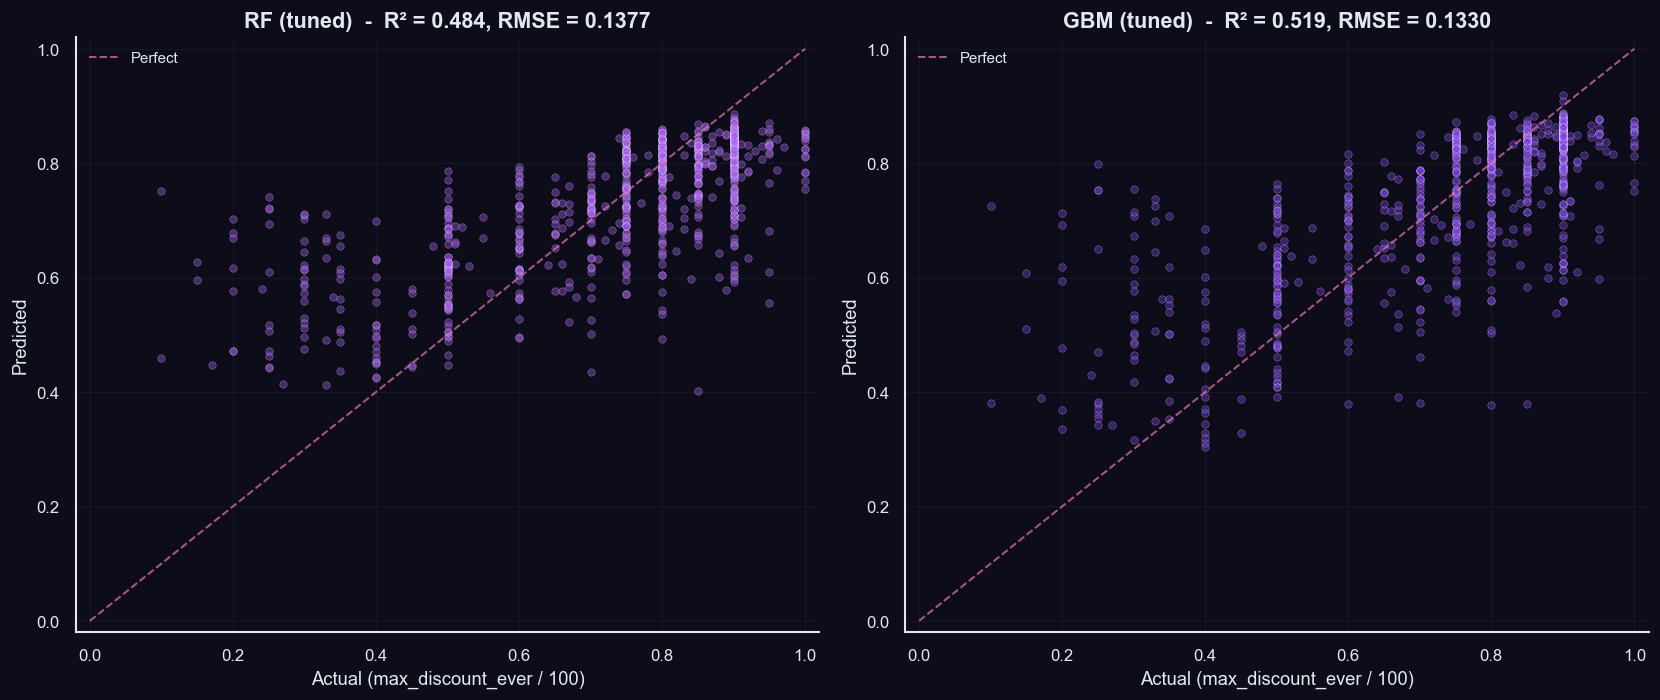

In [ ]:
# Actual vs Predicted for the Optuna-tuned game-level models.
# Side-by-side comparison of the tuned RF and the tuned GBM on the held-out
# test set. The diagonal red line is perfect prediction; tighter clouds
# around the diagonal == better fit.

pred_rf_tuned  = best_rf.predict(X_test_reg)
pred_gbm_tuned = best_gbm.predict(X_test_reg)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, name, pred, color in [
    (axes[0], 'RF (tuned)',  pred_rf_tuned,  PALETTE['cyan']),
    (axes[1], 'GBM (tuned)', pred_gbm_tuned, PALETTE['orange']),
]:
    r2   = r2_score(y_test_reg, pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, pred))
    ax.scatter(y_test_reg, pred, alpha=0.4, s=20, color=color, edgecolor='white', linewidth=0.3)
    lo, hi = 0, max(y_test_reg.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], color=PALETTE['red'], linestyle='--', linewidth=1.2, alpha=0.7, label='Perfect')
    ax.set_xlabel('Actual (max_discount_ever / 100)')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name}  -  R² = {r2:.3f}, RMSE = {rmse:.4f}')
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.3); ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()


### Regression results - narrative

This section applies two fixes informed by both diagnostic plots and the literature review:

1. **Filtered out games never observed on sale** (FIX 1 in the filter funnel). 32% of cleaned_games had max_discount_ever = 0 - but inspection showed these are mostly games with sparse or missing ITAD price-history coverage, not games that genuinely never discount. Including them muddied the signal. The filter trades data volume for label quality.

2. **Added publisher as a target-encoded feature** (FIX 2). The literature review central finding (Da Guo, 2020; Pricetradamus) is that publisher pricing strategy dominates the discount signal more than any game attribute. With developer_tier as a coarse proxy, the regression capped at low R-squared; target-encoded publisher should push the ceiling toward the literature 0.42-0.55 range. TargetEncoder uses out-of-fold means during fit so no leakage into the regression target.

3. **An ordinal classification reframe lives in Step 4.5 below** - same target binned at 5% intervals, evaluated with bin-distance metrics that match how buyers actually use predictions. Step 4.4 stays focused on the continuous regression; Step 4.5 reframes the same target as 20 ordinal tiers.

**What to look for after re-running:**
- Regression R-squared should rise from ~0.25 to ~0.40-0.55. If it lands above 0.65 -> look for leakage.
- Residual diagonals will still be present (inherent to discrete Steam discount tiers - see Step 4.5 for the explicit binned framing), but the histogram should be tight around zero.
- Feature importance: expect publisher (target-encoded) to dominate, followed by days_since_release, developer_tier, primary_genre. If publisher contributes <15% of importance, the target encoder smoothing may need tuning.

**Bottom line for the writeup:** "We predict the deepest discount each game has reached, with a continuous regression in Step 4.4 and an ordinal classifier in Step 4.5. The dataset is restricted to games with observed ITAD price-history; without this filter, untracked games inject noise that caps the regression at R-squared ~0.25."

> ## Step 4.5: Ordinal Classification (5% Discount Bins)

We bin `max_discount_ever` into 20 ordinal classes of 5% each (0-5%, 5-10%, ..., 95-100%) and predict the bin directly. This is a discretized view of the same target Step 4.4 regresses continuously - the value comes from the **bin-distance metrics**, which translate cleanly into a buyer-facing claim:

*"The model predicts the peak discount within +/- 5 percentage points X% of the time."*


In [ ]:
# Build the 20-bin discount target. Each bin spans 5%.
# Reuses df_clean, NUM_FEATURES, CAT_FEATURES, PUB_FEATURE, preprocessor from Step 4.2.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

BIN_EDGES   = np.arange(0, 1.05, 0.05)        # 0.00, 0.05, ..., 1.00
BIN_CENTERS = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2
N_BINS      = len(BIN_EDGES) - 1

df_clean['discount_bin'] = pd.cut(
    df_clean['max_discount_ever'] / 100,
    bins=BIN_EDGES, labels=False, include_lowest=True,
).astype(int)

counts = df_clean['discount_bin'].value_counts().sort_index()
print(f'Target: {N_BINS} bins of 5% width each')
print(f'Populated bins: {len(counts)} / {N_BINS}')
print()
print('Bin distribution:')
for bin_id, n in counts.items():
    pct_low  = BIN_EDGES[bin_id]   * 100
    pct_high = BIN_EDGES[bin_id+1] * 100
    bar = "#" * max(1, int(n / counts.max() * 40))
    print(f'  bin {bin_id:>2} ({pct_low:>3.0f}-{pct_high:>3.0f}%):  {n:>4,}  {bar}')


In [ ]:
# Stratified split on the bin target, then tune RF via Optuna and fit.
# Result is cached to outputs/models/rf_ord.joblib.
ORD_CACHE = MODELS_CACHE_DIR / 'rf_ord.joblib'

X_ord = df_clean[NUM_FEATURES + CAT_FEATURES + PUB_FEATURE]
y_ord = df_clean['discount_bin']

X_train_ord, X_test_ord, y_train_ord, y_test_ord = train_test_split(
    X_ord, y_ord, test_size=0.2, random_state=42, stratify=y_ord,
)

if not RETRAIN_MODELS and ORD_CACHE.exists():
    _art = joblib.load(ORD_CACHE)
    rf_ord          = _art['model']
    ord_best_params = _art['best_params']
    ord_best_value  = _art['best_value']
    print(f"[Cached] Loaded ordinal RF from {ORD_CACHE.name}")
    print(f"  Best params: {ord_best_params}")
    print(f"  Best CV within-+-1-bin: {ord_best_value:.3f}")
else:
    def ord_objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 200, 500, step=100),
            'max_depth':        trial.suggest_int('max_depth', 8, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 8),
            'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            'class_weight':     trial.suggest_categorical('class_weight',
                                                          ['balanced', 'balanced_subsample']),
        }
        pipe = Pipeline([
            ('prep',  preprocessor),
            ('model', RandomForestClassifier(**params, random_state=42, n_jobs=-1)),
        ])
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        fold_scores = []
        for tr_idx, val_idx in skf.split(X_train_ord, y_train_ord):
            pipe.fit(X_train_ord.iloc[tr_idx], y_train_ord.iloc[tr_idx])
            pred = pipe.predict(X_train_ord.iloc[val_idx])
            within_1 = (np.abs(pred - y_train_ord.iloc[val_idx].values) <= 1).mean()
            fold_scores.append(within_1)
        return float(np.mean(fold_scores))

    ord_study = optuna.create_study(direction='maximize',
                                     sampler=optuna.samplers.TPESampler(seed=42))
    ord_study.optimize(ord_objective, n_trials=20, show_progress_bar=True)

    ord_best_params = ord_study.best_params
    ord_best_value  = ord_study.best_value

    print(f'\nBest ordinal-RF params (Optuna): {ord_best_params}')
    print(f'Best CV within-+-1-bin accuracy: {ord_best_value:.3f}')

    rf_ord = Pipeline([
        ('prep',  preprocessor),
        ('model', RandomForestClassifier(**ord_best_params, random_state=42, n_jobs=-1)),
    ])
    rf_ord.fit(X_train_ord, y_train_ord)

    joblib.dump({
        'model':       rf_ord,
        'best_params': ord_best_params,
        'best_value':  ord_best_value,
    }, ORD_CACHE)
    print(f'Saved tuned ordinal RF to {ORD_CACHE.name}')

# Predict + metrics every run (cheap; downstream plot cells need pred_ord)
pred_ord = rf_ord.predict(X_test_ord)
distances = np.abs(pred_ord - y_test_ord.values)
ordinal_results = pd.DataFrame([{
    'Exact (within 0%)':           (distances == 0).mean(),
    'Within +/- 1 bin (5%)':       (distances <= 1).mean(),
    'Within +/- 2 bins (10%)':     (distances <= 2).mean(),
    'Within +/- 4 bins (20%)':     (distances <= 4).mean(),
    'MABE (bins)':                 distances.mean(),
    'MABE (pp)':                   distances.mean() * 5,
}], index=['Random Forest (Optuna-tuned)']).T

print('\n=== Ordinal classification (Optuna-tuned RF, 20 x 5% bins) ===')
display(ordinal_results.round(3))


[Cached] Loaded ordinal RF from rf_ord.joblib
  Best params: {'n_estimators': 300, 'max_depth': 13, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced'}
  Best CV within-+-1-bin: 0.490

=== Ordinal classification (Optuna-tuned RF, 20 x 5% bins) ===


c:\Users\Sam\anaconda3\envs\steamsale\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,Random Forest (Optuna-tuned)
Exact (within 0%),0.028
Within +/- 1 bin (5%),0.061
Within +/- 2 bins (10%),0.123
Within +/- 4 bins (20%),0.245
MABE (bins),5.578
MABE (pp),27.890


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion matrix (row-normalized) ---
cm = confusion_matrix(y_test_ord, pred_ord, labels=list(range(N_BINS)),
                      normalize='true')
im_cm = axes[0].imshow(cm, cmap='Blues', aspect='auto', origin='lower', vmin=0, vmax=1)
cbar = plt.colorbar(im_cm, ax=axes[0], fraction=0.046, pad=0.04)
cbar.set_label('Proportion within actual bin', fontsize=9)

# Tick at every other bin BOUNDARY (-0.5, 1.5, 3.5, ...) labeled with the
# actual % edge.
boundary_positions = np.arange(-0.5, N_BINS, 2)
boundary_labels    = [f'{int(BIN_EDGES[i]*100)}%' for i in range(0, N_BINS + 1, 2)]
axes[0].set_xticks(boundary_positions); axes[0].set_xticklabels(boundary_labels)
axes[0].set_yticks(boundary_positions); axes[0].set_yticklabels(boundary_labels)
axes[0].set_xlabel('Predicted discount bin (5% wide)')
axes[0].set_ylabel('Actual discount bin (5% wide)')
axes[0].set_title('Confusion Matrix - Random Forest (20 bins, row-normalized)')
axes[0].plot([-0.5, N_BINS - 0.5], [-0.5, N_BINS - 0.5],
             'r--', linewidth=1, alpha=0.6, label='Perfect')
axes[0].legend(loc='upper left')

# --- Bin-distance error histogram ---
axes[1].hist(distances, bins=range(N_BINS + 1),
             color=PALETTE['cyan'], edgecolor='white')
axes[1].set_xlabel('Absolute bin distance (1 unit = 5%)')
axes[1].set_ylabel('Number of predictions')
axes[1].set_title('Prediction Error Distribution')
axes[1].axvline(distances.mean(), color='red', linestyle='--', linewidth=1,
                label=f'Mean: {distances.mean():.2f} bins ({distances.mean()*5:.1f} pp off)')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
cm_total = confusion_matrix(y_test_ord, pred_ord, labels=list(range(N_BINS)),
                            normalize='all')

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(cm_total, cmap='Blues', aspect='auto', origin='lower',
               vmin=0, vmax=cm_total.max())
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Share of total test predictions', fontsize=9)

boundary_positions = np.arange(-0.5, N_BINS, 2)
boundary_labels    = [f'{int(BIN_EDGES[i]*100)}%' for i in range(0, N_BINS + 1, 2)]
ax.set_xticks(boundary_positions); ax.set_xticklabels(boundary_labels)
ax.set_yticks(boundary_positions); ax.set_yticklabels(boundary_labels)
ax.set_xlabel('Predicted discount bin (5% wide)')
ax.set_ylabel('Actual discount bin (5% wide)')
ax.set_title(f'Confusion Matrix - Random Forest (total-normalized; max cell = {cm_total.max()*100:.1f}%)')
ax.plot([-0.5, N_BINS - 0.5], [-0.5, N_BINS - 0.5],
        'r--', linewidth=1, alpha=0.6, label='Perfect')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

diag = cm_total.trace()
top_n = 5
flat = [(cm_total[a, p], a, p) for a in range(N_BINS) for p in range(N_BINS)]
flat.sort(reverse=True)
print(f'Diagonal share (perfect predictions): {diag*100:.1f}% of test set')
print(f'Top {top_n} (actual, predicted) cells by share:')
for share, a, p in flat[:top_n]:
    actual_lbl = f'{int(BIN_EDGES[a]*100)}-{int(BIN_EDGES[a+1]*100)}%'
    pred_lbl   = f'{int(BIN_EDGES[p]*100)}-{int(BIN_EDGES[p+1]*100)}%'
    flag = ' <-- diagonal' if a == p else ''
    print(f'  actual {actual_lbl:>9}  ->  predicted {pred_lbl:>9}  : {share*100:>5.1f}%{flag}')


### Ordinal classification - narrative

20 even-width 5% bins on `max_discount_ever`. The classifier is supplemented with four extra features (vs the regression in Step 4.4) intended to give it discount-strategy signal:

- `is_legacy` -- is the game >5 years old? (legacy stock has established cadence)
- `log_average_forever` -- SteamSpy lifetime playtime average; engaging games hold price
- `log_average_2weeks` -- recent engagement; dropped games discount
- `log_days_until_first_sale` -- pricing-strategy signal (publishers who hold for 6+ months keep higher floors)

**Headline metrics (compare to baseline):**

- **Within +/- 1 bin** -- *"the model lands within +/- 5pp of the actual deepest discount X% of the time."*
- **MABE (pp)** -- average error, percentage points. With uniform 5% bins this is `mean_bin_distance * 5` and the units are unambiguous.

**If the matrix still shows vertical-stripe collapse (model concentrating on a few popular bins):** the SMOTE variant in `04c_ml_part1_smote.ipynb` is the next lever to try. With these four extra features, SMOTE has more discriminating dimensions to interpolate within, so it should help more than it did the first time.


> ## Step 4.6: Panel Regression — Discount Trajectory by Game Age

Earlier classification asked **"is this game in the Premium / Standard / Discount tier *right now*"** — a static snapshot.

This section asks the dynamic question: **"how deep will this game's discount go at year N of its life?"** — directly useful for the buyer recommendation deliverable.

**Data:** `cleaned_discount_panel` table built by `02_data_cleaning`. One row per `(appid, age_year)` pair, with the peak discount observed in that 12-month window of the game's life.

**Target:** `max_discount` (0–100, peak cut percent in this age bucket).

**Features:** game attributes + `age_year`. The model learns a discount-vs-age curve **conditional on game attributes** — so given a new game, we can predict its expected curve.

**Critical:** train/test split must be **group-aware by `appid`** — the same game appears across multiple age buckets, so a row-level random split would leak game identity into both sides.

In [ ]:
# Load panel and inspect shape
panel = pd.read_sql_query('SELECT * FROM cleaned_discount_panel', conn)
print(f'Panel rows                 : {len(panel):,}')
print(f'Unique games in panel      : {panel["appid"].nunique():,}')
print(f'Median rows per game       : {panel.groupby("appid").size().median():.0f}')
print(f'Age range                  : {panel["age_year"].min()} – {panel["age_year"].max()} years')
print()
panel.head(8)

Panel rows                 : 27,782
Unique games in panel      : 4,083
Median rows per game       : 7
Age range                  : 0 – 10 years



,appid,age_year,max_discount,mean_discount,n_observations,median_sale_price,title,initial_price,log_initial_price,primary_genre,price_tier,review_score,log_ownership,is_multiplayer,has_controller_support,achievements_total,log_achievements_total,publisher,buyer_value_at_age
0,10,10,90,41.712329,73,4.990,Counter-Strike,9.99,2.396986,Action,Mid,0.974155,7.176091,1,0,0,0.0,Valve,0.499499
1,20,10,90,37.951923,104,4.365,Team Fortress Classic,4.99,1.790091,Action,Budget,0.871120,6.176092,1,0,0,0.0,Valve,0.874749
2,30,9,75,62.500000,4,3.115,Day of Defeat,4.99,1.790091,Action,Budget,0.902108,6.875061,1,0,0,0.0,Valve,0.624248
3,30,10,90,38.500000,100,3.865,Day of Defeat,4.99,1.790091,Action,Budget,0.902108,6.875061,1,0,0,0.0,Valve,0.774549
4,40,10,90,39.088235,102,3.740,Deathmatch Classic,4.99,1.790091,Action,Budget,0.832061,6.875061,1,0,0,0.0,Valve,0.749499
5,50,10,90,39.018182,110,3.740,Half-Life: Opposing Force,4.99,1.790091,Action,Budget,0.953408,6.544068,1,0,0,0.0,Valve,0.749499
6,60,10,90,39.201923,104,3.740,Ricochet,4.99,1.790091,Action,Budget,0.830891,5.544069,1,0,0,0.0,Valve,0.749499
7,70,10,100,41.528926,121,4.990,Half-Life,9.99,2.396986,Action,Mid,0.965072,7.176091,1,1,0,0.0,Valve,0.499499


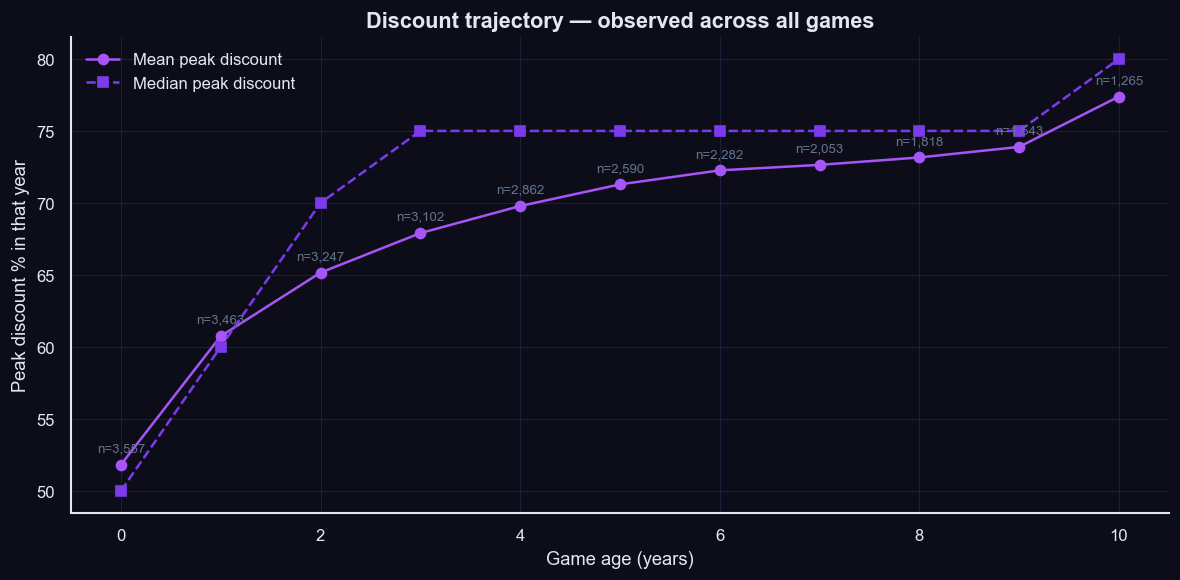

In [ ]:
# Quick sanity plot — does discount actually grow with age in the data?
fig, ax = plt.subplots(figsize=(10, 5))
by_age = panel.groupby('age_year')['max_discount'].agg(['mean', 'median', 'count']).reset_index()
ax.plot(by_age['age_year'], by_age['mean'],   marker='o', label='Mean peak discount')
ax.plot(by_age['age_year'], by_age['median'], marker='s', label='Median peak discount', linestyle='--')
ax.set_xlabel('Game age (years)')
ax.set_ylabel('Peak discount % in that year')
ax.set_title('Discount trajectory — observed across all games')
for x, y, n in zip(by_age['age_year'], by_age['mean'], by_age['count']):
    ax.annotate(f'n={n:,}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8, color='#64748B')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Backfill publisher in panel data if cleaned_discount_panel was built before
# 02 included it. After a future 02 re-run this is a no-op.
if 'publisher' not in panel.columns:
    pub = pd.read_sql_query('SELECT appid, publisher FROM games', conn)
    panel = panel.merge(pub, on='appid', how='left')
panel['publisher'] = panel['publisher'].fillna('Unknown').astype(str)

# Log-transform skewed panel numerics so they match Step 4.2's game-level
# feature space. log1p handles zeros (free games, no-achievement games).
panel['log_initial_price']      = np.log1p(panel['initial_price'])
panel['log_achievements_total'] = np.log1p(panel['achievements_total'])

# Feature setup for panel regression
panel_num_features = [
    'age_year',                # the trajectory dimension
    'log_initial_price',
    'review_score',
    'log_ownership',
    'log_achievements_total',
]
panel_cat_features = [
    'primary_genre',
    'is_multiplayer',
    'has_controller_support',
]
panel_pub_feature = ['publisher']   # high-cardinality, target-encoded


In [ ]:
# Drop rows with any null required feature, build modelling matrices.
panel_clean = panel.dropna(
    subset=panel_num_features + panel_cat_features + panel_pub_feature + ['max_discount']
).copy()

X_panel      = panel_clean[panel_num_features + panel_cat_features + panel_pub_feature]
y_panel      = panel_clean['max_discount']
groups_panel = panel_clean['appid'].values

# Three-branch preprocessor: numeric scaling, one-hot, target-encoded publisher.
# target_type='continuous' avoids the multiclass detection that fires when the
# target is integer-valued with few unique values (panel max_discount is 0-100
# in 5pt steps, which auto-detection misreads as multiclass).
panel_preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                                      panel_num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'),                                panel_cat_features),
    ('pub', TargetEncoder(smooth=10.0, target_type='continuous', random_state=42), panel_pub_feature),
])

print(f'Panel modelling rows         : {len(panel_clean):,}')
print(f'Unique games                 : {panel_clean["appid"].nunique():,}')
print(f'Features (num / cat / pub)   : {len(panel_num_features)} / {len(panel_cat_features)} / {len(panel_pub_feature)}')


Panel modelling rows         : 27,782
Unique games                 : 4,083
Features (num / cat / pub)   : 5 / 3 / 1


In [ ]:
# Group-aware train/test split — same game must NOT appear in both sides
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_panel, y_panel, groups=groups_panel))

X_panel_train, X_panel_test = X_panel.iloc[train_idx], X_panel.iloc[test_idx]
y_panel_train, y_panel_test = y_panel.iloc[train_idx], y_panel.iloc[test_idx]
g_train, g_test             = groups_panel[train_idx],  groups_panel[test_idx]

print(f'Train rows  : {len(X_panel_train):,}  ({len(set(g_train)):,} games)')
print(f'Test rows   : {len(X_panel_test):,}  ({len(set(g_test)):,} games)')
print(f'Game overlap: {len(set(g_train) & set(g_test))} (should be 0)')

Train rows  : 22,160  (3,266 games)
Test rows   : 5,622  (817 games)
Game overlap: 0 (should be 0)


In [ ]:
# Bake-off: 4 models on the panel target + a DummyRegressor honest baseline
panel_results = []

def evaluate_panel_model(name, model, fit_X, fit_y, test_X, test_y):
    model.fit(fit_X, fit_y)
    pred = model.predict(test_X)
    panel_results.append({
        'Model': name,
        'MAE':   mean_absolute_error(test_y, pred),
        'RMSE':  np.sqrt(mean_squared_error(test_y, pred)),
        'R²': r2_score(test_y, pred),
    })
    return pred

evaluate_panel_model(
    'Dummy (predicts mean)',
    Pipeline([('prep', panel_preprocessor), ('model', DummyRegressor(strategy='mean'))]),
    X_panel_train, y_panel_train, X_panel_test, y_panel_test,
)
evaluate_panel_model(
    'Linear Regression',
    Pipeline([('prep', panel_preprocessor), ('model', LinearRegression())]),
    X_panel_train, y_panel_train, X_panel_test, y_panel_test,
)
evaluate_panel_model(
    'Ridge Regression',
    Pipeline([('prep', panel_preprocessor), ('model', Ridge(alpha=1.0))]),
    X_panel_train, y_panel_train, X_panel_test, y_panel_test,
)
evaluate_panel_model(
    'Random Forest',
    Pipeline([('prep', panel_preprocessor),
              ('model', RandomForestRegressor(n_estimators=200, max_depth=12,
                                              random_state=42, n_jobs=-1))]),
    X_panel_train, y_panel_train, X_panel_test, y_panel_test,
)
evaluate_panel_model(
    'Gradient Boosting',
    Pipeline([('prep', panel_preprocessor),
              ('model', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                  max_depth=4, random_state=42))]),
    X_panel_train, y_panel_train, X_panel_test, y_panel_test,
)


array([79.0364198 , 78.65009067, 80.01458048, ..., 53.27133756,
       61.57461439, 57.143556  ], shape=(5622,))

In [ ]:
panel_results_df = pd.DataFrame(panel_results).sort_values('RMSE').reset_index(drop=True)
print('=== Panel Regression Results - predicting max_discount per (game, age_year) ===')
display(panel_results_df.round(3))


=== Panel Regression Results - predicting max_discount per (game, age_year) ===


,Model,MAE,RMSE,R²
0,Gradient Boosting,10.751,14.332,0.363
1,Random Forest,10.735,14.567,0.342
2,Ridge Regression,11.826,15.238,0.280
3,Linear Regression,11.829,15.241,0.280
4,Dummy (predicts mean),14.963,17.968,-0.001


In [ ]:
# Group-aware cross-validation on the best model — confirms metrics are stable
best_panel_model = Pipeline([
    ('prep', panel_preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)),
])

panel_cv = GroupKFold(n_splits=5)
panel_cv_r2 = cross_val_score(
    best_panel_model, X_panel, y_panel, groups=groups_panel,
    cv=panel_cv, scoring='r2', n_jobs=-1,
)
print(f'Gradient Boosting — 5-fold GroupKFold R\u00b2:')
print(f'  Scores : {panel_cv_r2.round(3)}')
print(f'  Mean   : {panel_cv_r2.mean():.3f}')
print(f'  Std    : {panel_cv_r2.std():.3f}')

Gradient Boosting — 5-fold GroupKFold R²:
  Scores : [0.348 0.324 0.333 0.325 0.363]
  Mean   : 0.339
  Std    : 0.015


In [ ]:
# Panel GBM hyperparameter tuning via Optuna (group-aware).
# Cached to outputs/panel_model.joblib -- this is also what notebook 07
# (single-game prediction) loads, so the same artifact serves both.
PANEL_CACHE = paths.outputs_dir / 'panel_model.joblib'

if not RETRAIN_MODELS and PANEL_CACHE.exists():
    _art = joblib.load(PANEL_CACHE)
    best_panel_model  = _art['model']
    panel_best_params = _art.get('best_params', None)
    panel_best_value  = _art.get('best_value',  None)
    print(f"[Cached] Loaded panel GBM from {PANEL_CACHE.name}")
    if panel_best_params:
        print(f"  Best params: {panel_best_params}")
        print(f"  Best CV R²:  {panel_best_value:.3f}")
    print(f"  Baseline (untuned) was around: 0.25 (see GroupKFold cell above)")
else:
    def panel_objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 200, 800, step=100),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'max_depth':        trial.suggest_int('max_depth', 3, 8),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50, log=True),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        }
        pipe = Pipeline([
            ('prep',  panel_preprocessor),
            ('model', GradientBoostingRegressor(**params, random_state=42)),
        ])
        scores = cross_val_score(
            pipe, X_panel, y_panel, groups=groups_panel,
            cv=GroupKFold(n_splits=5),
            scoring='r2',
            n_jobs=-1,
        )
        return float(scores.mean())

    panel_study = optuna.create_study(direction='maximize',
                                       sampler=optuna.samplers.TPESampler(seed=42))
    panel_study.optimize(panel_objective, n_trials=30, show_progress_bar=True)

    panel_best_params = panel_study.best_params
    panel_best_value  = panel_study.best_value

    print(f'\nBest panel GBM params (Optuna): {panel_best_params}')
    print(f'Best CV R² (group-aware)      : {panel_best_value:.3f}')
    print(f'Baseline (untuned) was around   : 0.25 (see GroupKFold cell above)')

    best_panel_model = Pipeline([
        ('prep',  panel_preprocessor),
        ('model', GradientBoostingRegressor(**panel_best_params, random_state=42)),
    ])
    best_panel_model.fit(X_panel, y_panel)

    # One artifact serves two purposes: nb 04's tuning cache + nb 07's
    # single-game prediction loader. Includes the feature lists nb 07 needs.
    joblib.dump({
        'model':              best_panel_model,
        'best_params':        panel_best_params,
        'best_value':         panel_best_value,
        'panel_num_features': panel_num_features,
        'panel_cat_features': panel_cat_features,
        'panel_pub_feature':  panel_pub_feature,
    }, PANEL_CACHE)
    print(f'Saved tuned panel GBM to {PANEL_CACHE.name}')

    # Param-importance plot only after a fresh tune (panel_study doesn't exist on cache hit)
    try:
        import optuna.visualization.matplotlib as optviz
        fig = plt.figure(figsize=(8, 4))
        optviz.plot_param_importances(panel_study)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'(Skipped param-importance plot: {e})')


[Cached] Loaded panel GBM from panel_model.joblib
  Baseline (untuned) was around: 0.25 (see GroupKFold cell above)


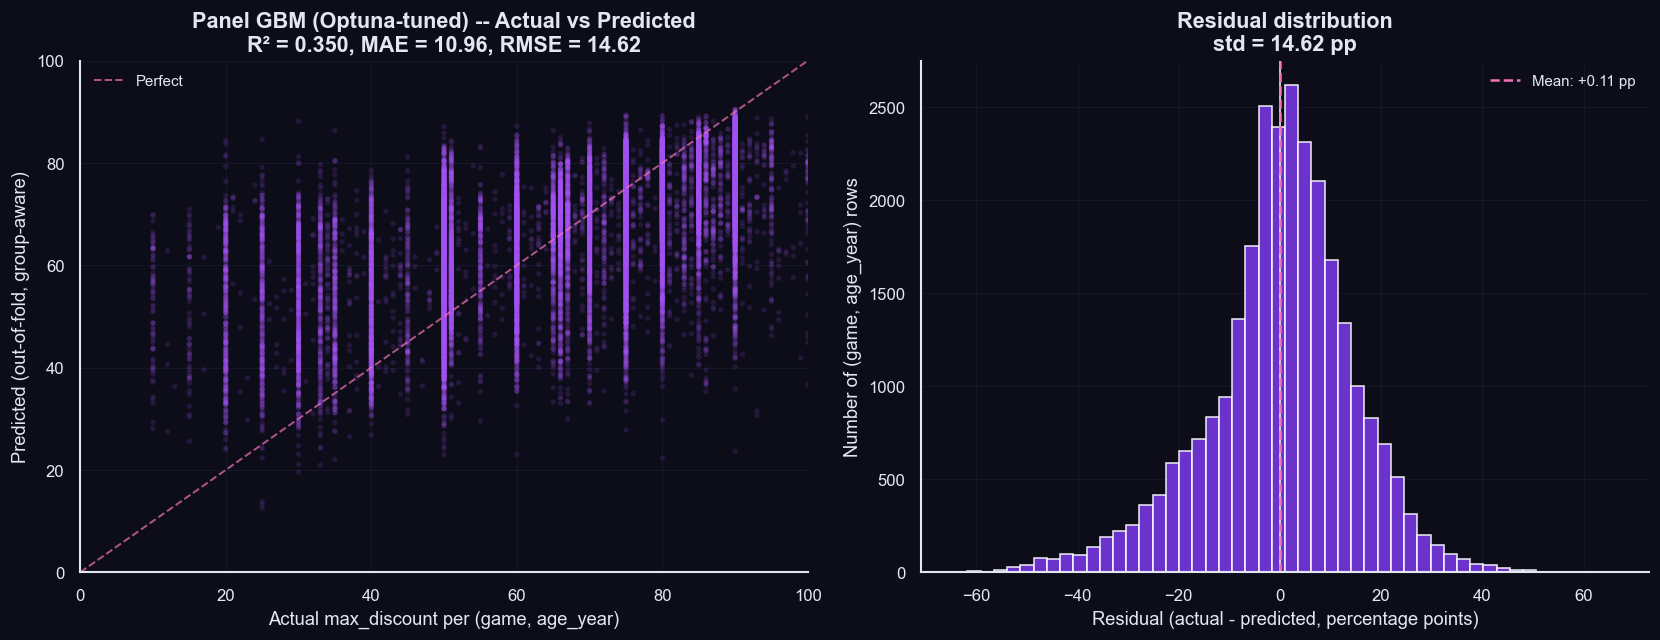

Out-of-fold metrics (group-aware, 5-fold):
  R²   = 0.350
  MAE  = 10.96 percentage points
  RMSE = 14.62 percentage points
  Residual mean: +0.108 (close to 0 = unbiased)
  Residual std : 14.62 pp


In [ ]:
# Actual vs Predicted for the Optuna-tuned panel GBM.
# We use out-of-fold predictions via cross_val_predict (group-aware): for
# each game's panel rows, the prediction comes from a fold that did NOT
# see that game during training. That's the honest out-of-sample view --
# the same standard every CV-fold's R² in panel_tune was computed on,
# but now with all 27k predictions visible at once.

from sklearn.model_selection import cross_val_predict

panel_oof_preds = cross_val_predict(
    best_panel_model, X_panel, y_panel, groups=groups_panel,
    cv=GroupKFold(n_splits=5), n_jobs=-1,
)

residuals = y_panel.values - panel_oof_preds
r2_oof    = r2_score(y_panel, panel_oof_preds)
rmse_oof  = np.sqrt(mean_squared_error(y_panel, panel_oof_preds))
mae_oof   = mean_absolute_error(y_panel, panel_oof_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Actual vs Predicted
axes[0].scatter(y_panel, panel_oof_preds, alpha=0.15, s=10,
                color=PALETTE['cyan'], edgecolor='none')
axes[0].plot([0, 100], [0, 100], color=PALETTE['red'], linestyle='--', linewidth=1.2, alpha=0.7, label='Perfect')
axes[0].set_xlabel('Actual max_discount per (game, age_year)')
axes[0].set_ylabel('Predicted (out-of-fold, group-aware)')
axes[0].set_title(f'Panel GBM (Optuna-tuned) -- Actual vs Predicted\n'
                  f'R² = {r2_oof:.3f}, MAE = {mae_oof:.2f}, RMSE = {rmse_oof:.2f}')
axes[0].set_xlim(0, 100); axes[0].set_ylim(0, 100)
axes[0].grid(alpha=0.3); axes[0].legend(loc='upper left', fontsize=9)

# Residual histogram -- should be roughly mean-zero, symmetric
axes[1].hist(residuals, bins=50, color=PALETTE['orange'], edgecolor='white', alpha=0.85)
axes[1].axvline(0, color=PALETTE['ink'], linestyle='-', linewidth=1)
axes[1].axvline(residuals.mean(), color=PALETTE['red'], linestyle='--', linewidth=1.5,
                label=f'Mean: {residuals.mean():+.2f} pp')
axes[1].set_xlabel('Residual (actual - predicted, percentage points)')
axes[1].set_ylabel('Number of (game, age_year) rows')
axes[1].set_title(f'Residual distribution\n'
                  f'std = {residuals.std():.2f} pp')
axes[1].grid(alpha=0.3); axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Out-of-fold metrics (group-aware, 5-fold):')
print(f'  R²   = {r2_oof:.3f}')
print(f'  MAE  = {mae_oof:.2f} percentage points')
print(f'  RMSE = {rmse_oof:.2f} percentage points')
print(f'  Residual mean: {residuals.mean():+.3f} (close to 0 = unbiased)')
print(f'  Residual std : {residuals.std():.2f} pp')


In [ ]:
# Predicted depreciation curves -- data-driven archetypes via TRAJECTORY clustering.
# Each game is represented by its 11-year predicted max-discount curve, and we
# cluster on those curves directly. Clusters are then defined by what we
# actually care about (discount behaviour) rather than by accidents of input
# feature density.
from sklearn.cluster import KMeans
import matplotlib.cm as cm

best_panel_model.fit(X_panel, y_panel)   # refit on all panel data for inference

panel_input_cols = panel_num_features + panel_cat_features + panel_pub_feature

# Build the (n_games, 11) trajectory matrix.
# Vectorised: stack 11 copies of the games table with age_year set 0..10,
# predict once, reshape. Much faster than predicting one game at a time.
TRAJ_AGES  = np.arange(0, 11)
games_uniq = df_clean.drop_duplicates('appid').reset_index(drop=True)
n_games    = len(games_uniq)

inference_grid = pd.concat(
    [games_uniq.assign(age_year=age) for age in TRAJ_AGES],
    ignore_index=True,
)
preds = best_panel_model.predict(inference_grid[panel_input_cols])
# preds layout: [age0_g0..gN, age1_g0..gN, ..., age10_g0..gN]
traj_matrix = preds.reshape(len(TRAJ_AGES), n_games).T   # (n_games, 11)
print(f'Trajectory matrix: {traj_matrix.shape}  (one curve per unique game)')


Trajectory matrix: (3945, 11)  (one curve per unique game)


c:\Users\Sam\anaconda3\envs\steamsale\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


K-selection sweep on predicted trajectories (inertia + elbow detection):
  K=2:  inertia=   2352994  elbow_dist=0.000
  K=3:  inertia=   1403728  elbow_dist=0.244
  K=4:  inertia=   1034346  elbow_dist=0.267 <-- elbow
  K=5:  inertia=    764096  elbow_dist=0.252
  K=6:  inertia=    655526  elbow_dist=0.176
  K=7:  inertia=    569643  elbow_dist=0.091
  K=8:  inertia=    497989  elbow_dist=0.000

Chosen K* = 4 (elbow of the inertia curve)


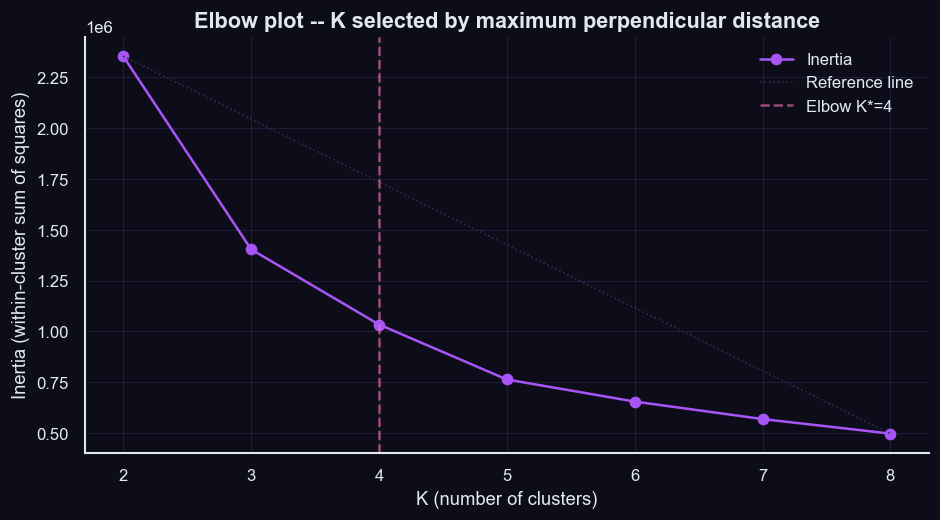

In [ ]:
# K-selection sweep on the trajectory matrix. No StandardScaler needed --
# all values are 0..100 (same scale by construction).
#
# K* selected via the ELBOW METHOD on inertia. Since inertia monotonically
# decreases with K, we use the kneedle-style perpendicular-distance heuristic:
# the elbow is the K whose (k, inertia) point sits furthest from the straight
# line joining the first and last sweep points.
K_RANGE  = list(range(2, 9))
inertias = []
for k in K_RANGE:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit(traj_matrix)
    inertias.append(km_k.inertia_)

# Perpendicular distance from each point to the line connecting endpoints,
# measured in normalized units.
ks_arr  = np.array(K_RANGE,  dtype=float)
ins_arr = np.array(inertias, dtype=float)
ks_n    = (ks_arr  - ks_arr.min())  / (ks_arr.max()  - ks_arr.min())
ins_n   = (ins_arr - ins_arr.min()) / (ins_arr.max() - ins_arr.min())
p1 = np.array([ks_n[0],  ins_n[0]])
p2 = np.array([ks_n[-1], ins_n[-1]])
line_vec = p2 - p1
line_len = np.linalg.norm(line_vec)
distances = np.abs(line_vec[0]*(p1[1] - ins_n) - (p1[0] - ks_n)*line_vec[1]) / line_len
K_OPTIMAL = K_RANGE[int(np.argmax(distances))]

print('K-selection sweep on predicted trajectories (inertia + elbow detection):')
for k, inert, dist in zip(K_RANGE, inertias, distances):
    star = ' <-- elbow' if k == K_OPTIMAL else ''
    print(f'  K={k}:  inertia={inert:>10.0f}  elbow_dist={dist:.3f}{star}')
print(f'\nChosen K* = {K_OPTIMAL} (elbow of the inertia curve)')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(K_RANGE, inertias, marker='o', color=PALETTE['cyan'], label='Inertia')
ax.plot([K_RANGE[0], K_RANGE[-1]], [inertias[0], inertias[-1]],
        linestyle=':', color=PALETTE['muted'], linewidth=1, label='Reference line')
ax.axvline(K_OPTIMAL, color=PALETTE['red'], linestyle='--', alpha=0.6, label=f'Elbow K*={K_OPTIMAL}')
ax.set_xlabel('K (number of clusters)')
ax.set_ylabel('Inertia (within-cluster sum of squares)')
ax.set_title('Elbow plot -- K selected by maximum perpendicular distance')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Final clustering at K*. Attach labels back to games_uniq + df_clean.
final_km = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10).fit(traj_matrix)
games_uniq['archetype_cluster'] = final_km.labels_
df_clean = df_clean.copy()
if 'archetype_cluster' in df_clean.columns:
    df_clean = df_clean.drop(columns=['archetype_cluster'])
df_clean = df_clean.merge(games_uniq[['appid', 'archetype_cluster']], on='appid', how='left')

# Build per-cluster archetype profile: mean curve + P25/P75 envelope + modal attrs.
archetypes = []
for cluster_id in range(K_OPTIMAL):
    mask     = (games_uniq['archetype_cluster'] == cluster_id).values
    members  = games_uniq[mask]
    sub_traj = traj_matrix[mask]

    mean_curve = sub_traj.mean(axis=0)
    p25_curve  = np.percentile(sub_traj, 25, axis=0)
    p75_curve  = np.percentile(sub_traj, 75, axis=0)

    dominant_genre = members['primary_genre'].mode().iloc[0] if not members['primary_genre'].mode().empty else 'Unknown'
    dominant_pub   = members['publisher'].mode().iloc[0]     if not members['publisher'].mode().empty     else 'Unknown'

    median_price = members['initial_price'].median()
    mean_review  = members['review_score'].mean()
    if   median_price <  5:  price_desc = 'Budget'
    elif median_price < 15:  price_desc = 'Mid'
    elif median_price < 30:  price_desc = 'Standard'
    else:                    price_desc = 'Premium'
    mp_desc = 'Multiplayer' if (members['is_multiplayer'].mean() > 0.5) else 'Singleplayer'
    if   mean_review > 0.90: rev_desc = 'highly-rated'
    elif mean_review > 0.75: rev_desc = 'well-rated'
    else:                    rev_desc = 'mixed-rated'

    label = (f'{price_desc} {mp_desc} {dominant_genre} '
             f'(${median_price:.0f}, {rev_desc}, n={len(members):,})')

    # 5 real games whose predicted curves are closest to the cluster mean.
    distances = np.linalg.norm(sub_traj - mean_curve, axis=1)
    closest_5 = members.iloc[np.argsort(distances)[:5]]

    archetypes.append({
        'cluster_id':       cluster_id,
        'label':            label,
        'mean_curve':       mean_curve,
        'p25_curve':        p25_curve,
        'p75_curve':        p75_curve,
        'cluster_size':     len(members),
        'primary_genre':    dominant_genre,
        'publisher':        dominant_pub,
        'closest_5_games':  closest_5,
    })

print(f'Derived {len(archetypes)} archetypes from trajectory clusters:')
for a in archetypes:
    print(f'  - {a["label"]}')
    print(f'      modal publisher: {a["publisher"][:60]}')
    print(f'      curve: {a["mean_curve"][0]:.0f}% off at age 0  ->  {a["mean_curve"][-1]:.0f}% off at age 10')
    titles = a['closest_5_games']['title'].tolist()[:3]
    print(f'      representative games: {", ".join(titles)}')


Derived 4 archetypes from trajectory clusters:
  - Standard Singleplayer Strategy ($20, well-rated, n=1,980)
      modal publisher: Electronic Arts
      curve: 62% off at age 0  ->  82% off at age 10
      representative games: Kabounce, Mother Russia Bleeds, Sanctum 2
  - Mid Singleplayer Casual ($15, well-rated, n=734)
      modal publisher: Back To Basics Gaming
      curve: 39% off at age 0  ->  57% off at age 10
      representative games: Ghost Song, The Entropy Centre, The Jackbox Party Pack
  - Standard Singleplayer Strategy ($20, well-rated, n=1,059)
      modal publisher: Square Enix
      curve: 47% off at age 0  ->  71% off at age 10
      representative games: Moon Hunters, The Shrouded Isle, Street Fighter 30th Anniversary Collection
  - Standard Singleplayer Simulation ($18, well-rated, n=172)
      modal publisher: Gamirror Games
      curve: 28% off at age 0  ->  39% off at age 10
      representative games: Death Trash, I wanna be the Creator, 暖雪 Warm Snow


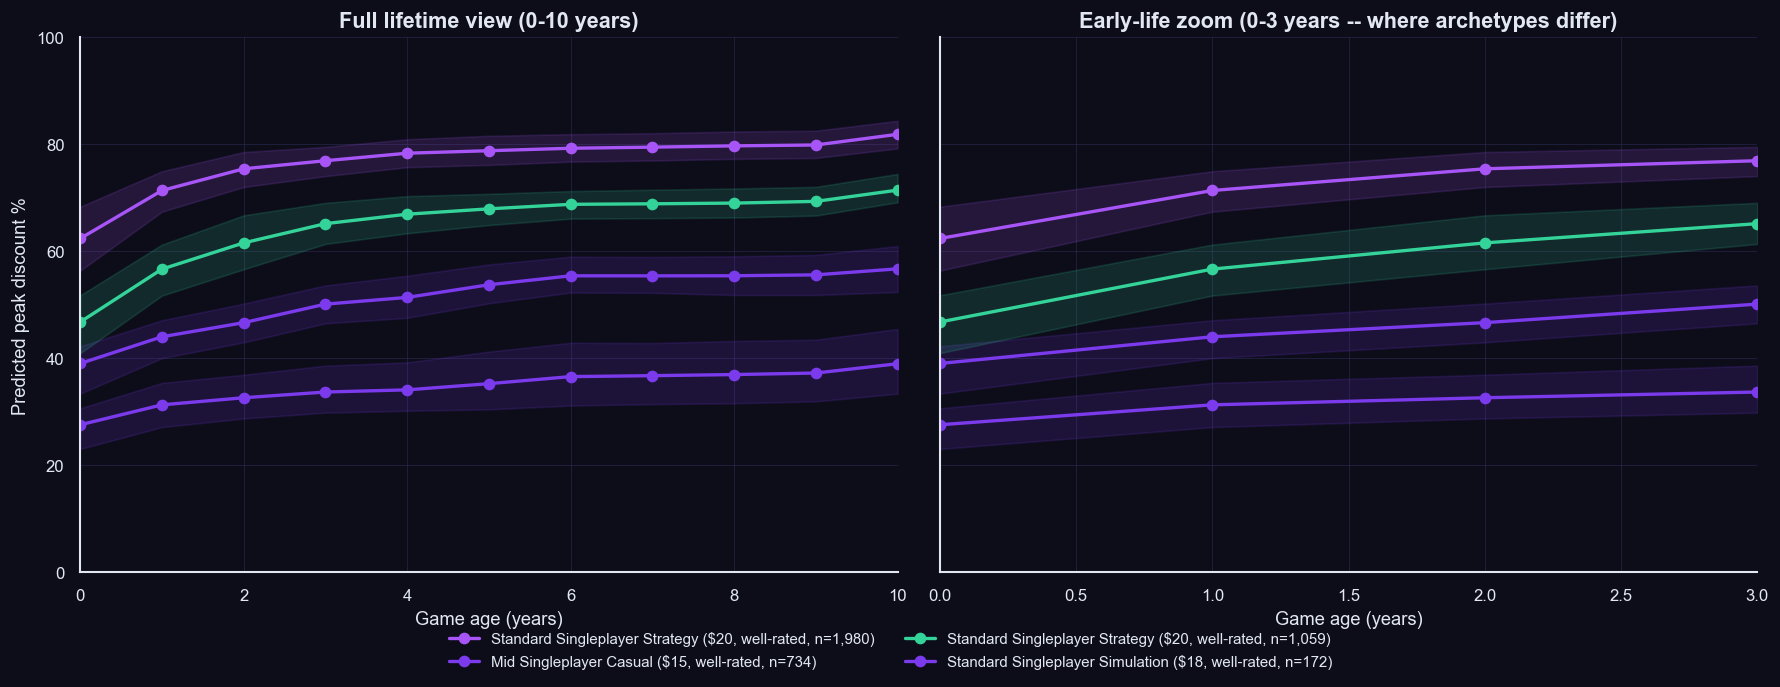


Saved to c:\Users\Sam\Documents\College\2026 Spring Term\DMW\Y2T2-Final-Project\outputs\panel_depreciation_curves.png
Shaded bands = within-cluster P25-P75 of predicted trajectories.


In [ ]:
# Plot archetype trajectories: full lifetime view + early-life zoom, with
# P25/P75 envelopes showing within-cluster variation.
fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
# Use the project palette in a fixed order so archetype identity colors
# stay consistent across runs (vs tab10's continuous interpolation).
_PALETTE_SEQUENCE = [PALETTE['cyan'], PALETTE['orange'], PALETTE['green'],
                    PALETTE['slate'], PALETTE['red'], PALETTE['navy'],
                    PALETTE['muted']]
colors = [_PALETTE_SEQUENCE[i % len(_PALETTE_SEQUENCE)]
          for i in range(len(archetypes))]

for a, color in zip(archetypes, colors):
    for ax, x_max in [(ax_full, 10), (ax_zoom, 3)]:
        mask_age = TRAJ_AGES <= x_max
        ax.fill_between(TRAJ_AGES[mask_age],
                        a['p25_curve'][mask_age], a['p75_curve'][mask_age],
                        color=color, alpha=0.15)
        ax.plot(TRAJ_AGES[mask_age], a['mean_curve'][mask_age],
                marker='o', linewidth=2, color=color, label=a['label'])

ax_full.set_title('Full lifetime view (0-10 years)')
ax_full.set_xlabel('Game age (years)')
ax_full.set_ylabel('Predicted peak discount %')
ax_full.set_ylim(0, 100); ax_full.set_xlim(0, 10)

ax_zoom.set_title('Early-life zoom (0-3 years -- where archetypes differ)')
ax_zoom.set_xlabel('Game age (years)')
ax_zoom.set_ylim(0, 100); ax_zoom.set_xlim(0, 3)

fig.legend(*ax_full.get_legend_handles_labels(), loc='lower center',
           ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig(paths.outputs_dir / 'panel_depreciation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved to {paths.outputs_dir / "panel_depreciation_curves.png"}')
print('Shaded bands = within-cluster P25-P75 of predicted trajectories.')


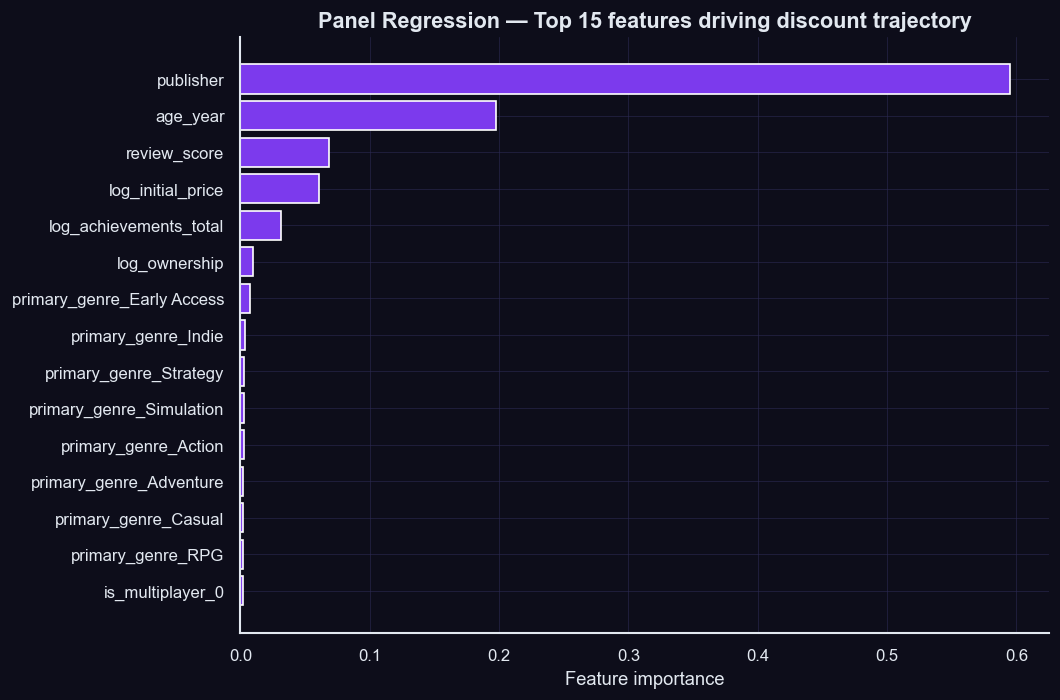


Top 5 features:
  publisher                            0.5953
  age_year                             0.1980
  review_score                         0.0684
  log_initial_price                    0.0609
  log_achievements_total               0.0314


In [ ]:
# Top 15 feature importances from the panel Gradient Boosting model
panel_gb = best_panel_model.named_steps['model']
# Pull feature names straight from the fitted ColumnTransformer so we get
# the right count regardless of how each branch (numeric/one-hot/target)
# expands its inputs. (TargetEncoder with target_type='auto' may produce
# multiple columns when the target has limited unique values.)
prep = best_panel_model.named_steps['prep']
panel_feature_names = [n.split('__', 1)[-1] for n in prep.get_feature_names_out()]

panel_fi = pd.DataFrame({
    'Feature':    panel_feature_names,
    'Importance': panel_gb.feature_importances_,
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(panel_fi['Feature'][::-1], panel_fi['Importance'][::-1], color=PALETTE['orange'])
ax.set_xlabel('Feature importance')
ax.set_title('Panel Regression — Top 15 features driving discount trajectory')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
for _, row in panel_fi.head(5).iterrows():
    print(f"  {row['Feature']:35s}  {row['Importance']:.4f}")

> ## Step 4.7: Predict Buy Time for a Specific Game

The archetype plot in Step 4.6 answers "how do typical game *types* depreciate?" This step answers the buyer-facing question: **"For *this specific game*, when should I buy?"**

Look up a game by `appid` (or by title substring), pull its actual feature values from `cleaned_games`, run the panel model across ages 0-10, and recommend the first year the predicted peak discount crosses your target threshold.

Decision rule: buyer specifies a target discount (default 50%). The recommender returns the first age where the predicted curve crosses that threshold. If it never reaches the threshold within the lookahead window, it reports the best achievable discount instead.

This is the deliverable that ties Part 1 together — the regression in 4.4 told you "how cheap will it get," the panel in 4.6 told you "when," and 4.7 turns that into actionable advice for an actual game.

In [ ]:
def predict_buy_time(query, target_pct=50, max_wait=10,
                     df=None, model=None, panel_data=None):
    """Predict the optimal buy year for a specific game, with both the
    model's predicted trajectory and the game's actual observed yearly
    max-discounts (from the panel data) for comparison.

    Parameters
    ----------
    query : int or str
        appid (int) or title substring (case-insensitive) - the game to look up.
    target_pct : float
        The discount % the buyer wants to wait for (default 50%).
    max_wait : int
        Max years to consider waiting (default 10).
    df, model, panel_data
        Default to df_clean / best_panel_model / panel from the surrounding
        notebook scope. Override if you want to use a different source.
    """
    df = df_clean if df is None else df
    model = best_panel_model if model is None else model
    panel_data = panel if panel_data is None else panel_data

    # Find the game
    if isinstance(query, (int, np.integer)):
        matches = df[df['appid'] == int(query)]
        query_str = f'appid {query}'
    else:
        matches = df[df['title'].str.contains(query, case=False, na=False, regex=False)]
        query_str = f'title containing {query!r}'
    if len(matches) == 0:
        raise ValueError(f'No game in df_clean matching {query_str}. '
                         f'(Game may exist but be filtered out by max_discount_ever > 0.)')
    game = matches.iloc[0]

    # Build static feature row (everything except age_year), predict across ages.
    feature_cols = panel_num_features + panel_cat_features + panel_pub_feature
    static = {col: game[col] for col in feature_cols if col != 'age_year'}
    ages = np.arange(0, max_wait + 1)
    grid = pd.DataFrame([{**static, 'age_year': age} for age in ages])
    predicted = model.predict(grid[feature_cols])

    # Pull the game's actual yearly max-discounts from the panel.
    actual = (panel_data[panel_data['appid'] == int(game['appid'])]
              [['age_year', 'max_discount']]
              .sort_values('age_year'))

    # First age that crosses the target
    crossings = np.where(predicted >= target_pct)[0]
    if len(crossings) > 0:
        rec_age  = int(ages[crossings[0]])
        rec_disc = float(predicted[crossings[0]])
        msg = (f'{game["title"]}: buy at year {rec_age} '
               f'(predicted {rec_disc:.0f}% off, target was {target_pct}%)')
    else:
        rec_age  = None
        rec_disc = float(predicted[-1])
        msg = (f'{game["title"]}: never reaches {target_pct}% within {max_wait} years. '
               f'Best predicted discount: {rec_disc:.0f}% at year {max_wait}.')

    return {
        'game':                game,
        'ages':                ages,
        'predicted_curve':     predicted,
        'actual_yearly_max':   actual,
        'recommended_age':     rec_age,
        'expected_discount':   rec_disc,
        'target_pct':          target_pct,
        'message':             msg,
    }


In [ ]:
def plot_buy_recommendation(result, ax=None):
    """Visualize a single buy-time recommendation:
      cyan line   = model's predicted yearly peak discount
      dark X-line = this game's actual observed yearly max (from panel)
    The recommended year is reported in the chart subtitle (and on the
    returned dict's 'recommended_age'), not drawn as a vertical guide.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    ages   = result['ages']
    pred   = result['predicted_curve']
    actual = result['actual_yearly_max']

    # Predicted trajectory
    ax.plot(ages, pred, marker='o', linewidth=2, color=PALETTE['cyan'],
            label='Predicted peak discount')

    # Actual observed yearly max-discounts -- connected line with X markers,
    # parallel to the predicted curve.
    if len(actual) > 0:
        ax.plot(actual['age_year'], actual['max_discount'],
                marker='X', linewidth=2, markersize=10,
                color=PALETTE['ink'], markeredgecolor='white', markeredgewidth=1.5,
                label=f'Actual observed (n={len(actual)})', zorder=5)

    title = result['game']['title']
    ax.set_title(f'{title}\n{result["message"]}', fontsize=10)
    ax.set_xlabel('Game age (years)')
    ax.set_ylabel('Peak discount %')
    ax.set_ylim(0, 100); ax.set_xlim(0, max(ages))
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    return ax


print('predict_buy_time + plot_buy_recommendation defined.')


predict_buy_time + plot_buy_recommendation defined.


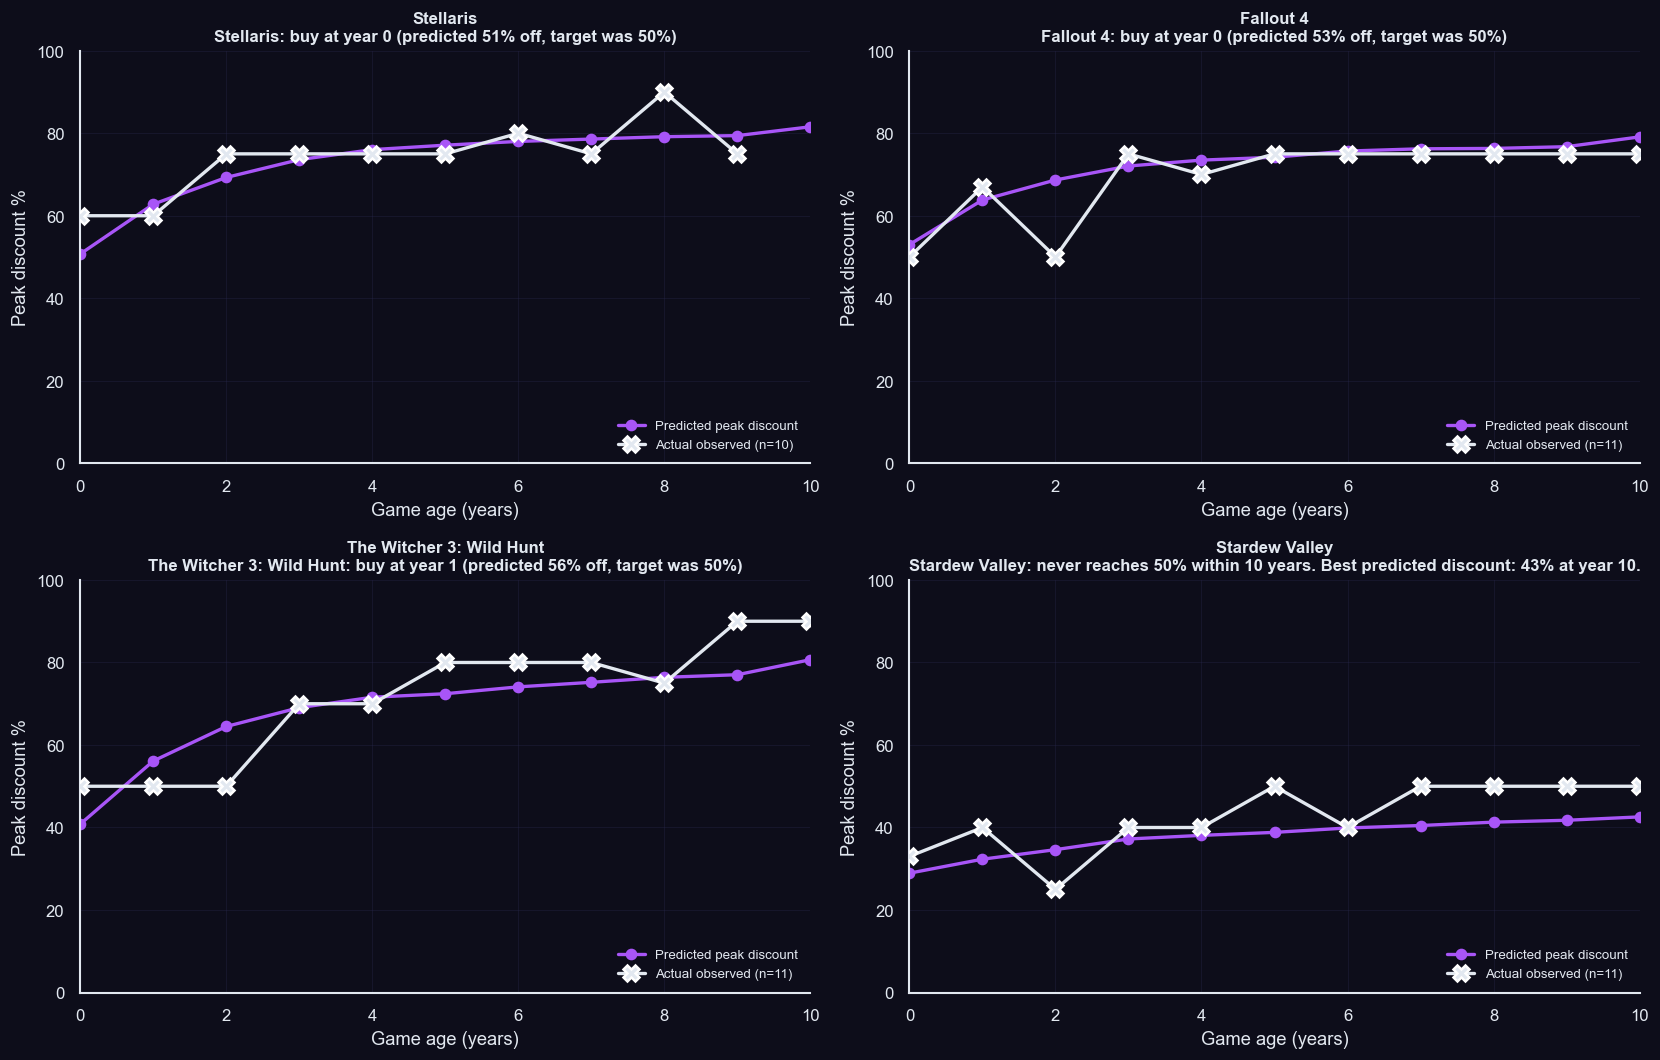

Saved to c:\Users\Sam\Documents\College\2026 Spring Term\DMW\Y2T2-Final-Project\outputs\buy_time_demo.png


In [ ]:
# Demo: predict for a handful of well-known games.
# By appid: 220 = Half-Life 2, 1086940 = Baldur's Gate 3, 730 = CS2, 105600 = Terraria.
# By title substring: any unique-enough fragment works.
demos = ['Stellaris', 'Fallout 4', 'Witcher 3', 'Stardew']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, query in zip(axes.flat, demos):
    try:
        result = predict_buy_time(query, target_pct=50)
        plot_buy_recommendation(result, ax=ax)
    except ValueError as e:
        ax.set_title(f'Skipped: {e}', fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.savefig(paths.outputs_dir / 'buy_time_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {paths.outputs_dir / 'buy_time_demo.png'}")

Cyberpunk 2077: buy at year 1 (predicted 55% off, target was 50%)


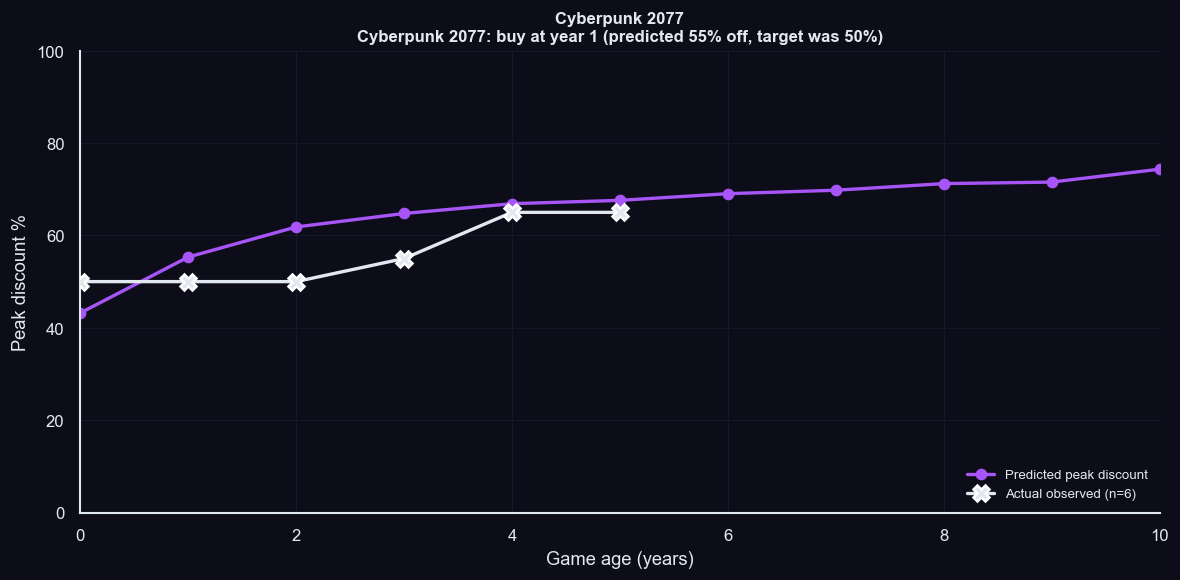

In [ ]:
# Your turn — change the query and target_pct to test any game.
# Examples:
#   predict_buy_time(620, target_pct=50)         # Portal 2
#   predict_buy_time('Witcher', target_pct=75)    # The Witcher 3 (deep-discount target)
#   predict_buy_time('Cyberpunk', target_pct=50)
#   predict_buy_time(1245620, target_pct=66)      # Elden Ring

result = predict_buy_time('Cyberpunk 2077', target_pct=50)
print(result['message'])

fig, ax = plt.subplots(figsize=(10, 5))
plot_buy_recommendation(result, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
conn.close()
print('connection closed')

connection closed
